# ESS Battery Health - Batch Comparison

목표 : `batch1 + batch2 + batch3`를 합쳐 5개 질문에 대한 EDA를 수행하고, batch 간 차이를 비교한 뒤 모델 설계 전략까지 정리합니다.

## DAY 1 - 모델 전략 수립
- 대상 Dataset : `Batch 1 + Batch 2 + Batch 3`
- 질문 5개에 대해 각 Batch Set의 특징을 비교
- EDA insight를 바탕으로 feature engineering, target 정의, modeling strategy를 제안


## 목차

1. Cycle Life 분포는 어떻게 생겼는가?
1.1 150 ~ 2,300 사이클 Histogram
1.2 장수명(>1,000)/단수명(<500) 비율 확인
1.3 이상치 셀 식별 - 왜 유독 짧은가?

2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?
2.1 사이클 별 Qd 추이 시각화
2.2 열화 속도가 일정한가, 가속되는가?
2.3 Knee point - 급격한 열화 시작점 탐색

3. ΔQ(V) 곡선 - 초기 사이클에서 차이가 보이는가?
3.1 사이클 100번 - 사이클 10번의 Q(V) 차이 계산
3.2 장수명 셀 vs 단수명 셀의 ΔQ 형태 비교
3.3 이를 구분할 수 있는 통계값으로 피쳐 추출

4. 충전 조건 (C-rate)과 수명의 관계는?
4.1 충전 프로토콜별 평균 수명 비교
4.2 고속 충전 셀이 정말 수명이 짧은가?
4.3 충전 전류 패턴과 열화 속도 상관 분석

5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?
5.1 초기 사이클 피쳐들과 Cycle Life 상관 계수 확인
5.2 가장 강한 관계 식별
5.3 멀티클리니어리티 문제 확인


In [7]:
import numpy as np
import pandas as pd
import mat73                      
import scipy.io as sio            
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [8]:
DATA_DIR = './archive'
FILES = {
    'batch1': '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    'batch2': '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    'batch3': '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}


In [9]:
def load_mat(path):
    try:
        return mat73.loadmat(path)
    except Exception:
        return sio.loadmat(path, simplify_cells=True)

def to_list_of_dicts(d):
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d

def to_float_array(values):
    arr = np.asarray(values, dtype=float).squeeze()
    if arr.ndim == 0:
        arr = np.array([float(arr)])
    return arr

def extract_summary(batch):
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        if isinstance(summary, dict):
            qd = np.array(summary['QDischarge']); qc = np.array(summary['QCharge']); ir = np.array(summary['IR'])
            tmax = np.array(summary['Tmax']); tavg = np.array(summary['Tavg']); tmin = np.array(summary['Tmin']); ct = np.array(summary['chargetime'])
        else:
            qd = summary['QDischarge']; qc = summary['QCharge']; ir = summary['IR']
            tmax = summary['Tmax']; tavg = summary['Tavg']; tmin = summary['Tmin']; ct = summary['chargetime']
        cycle_life = cell['cycle_life']
        if pd.isna(cycle_life):
            continue
        policy = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        for c in range(len(qd)):
            records.append({
                'cell_id': i, 'cycle': c + 1, 'cycle_life': int(cycle_life), 'charging_policy': policy,
                'QD': qd[c], 'QC': qc[c], 'IR': ir[c], 'Tmax': tmax[c], 'Tavg': tavg[c], 'Tmin': tmin[c], 'chargetime': ct[c]
            })
    return pd.DataFrame(records)

def get_cell_cycles(cell):
    return to_list_of_dicts(cell['cycles'])

import re

def parse_policy_features(policy):
    policy = str(policy)
    rates = [float(x) for x in re.findall(r'(\d+(?:\.\d+)?)C', policy)]
    switches = [float(x) for x in re.findall(r'\((\d+)%\)', policy)]
    return {
        'max_c_rate': max(rates) if rates else np.nan,
        'mean_c_rate': float(np.mean(rates)) if rates else np.nan,
        'switch_soc_pct': switches[0] if switches else np.nan,
        'policy_steps': len(rates),
    }

def enrich_cycle_life_table(cycle_life_df):
    parsed = cycle_life_df['charging_policy'].apply(parse_policy_features).apply(pd.Series)
    return pd.concat([cycle_life_df.reset_index(drop=True), parsed], axis=1)

def find_knee_point(cycles, qd, min_cycle=80, window=25, acceleration_factor=2.0):
    cycles = to_float_array(cycles); qd = to_float_array(qd)
    if len(cycles) < max(window, min_cycle):
        return np.nan, np.nan, np.nan
    smooth = pd.Series(qd).rolling(window=window, center=True, min_periods=max(5, window // 3)).median().bfill().ffill().to_numpy()
    slope = np.gradient(smooth, cycles)
    early_mask = (cycles >= 10) & (cycles <= min(100, cycles.max()))
    baseline = np.nanmedian(slope[early_mask]) if early_mask.any() else np.nanmedian(slope[:window])
    if np.isnan(baseline) or baseline >= 0:
        return np.nan, baseline, np.nan
    accelerated = np.where((cycles >= min_cycle) & (slope <= acceleration_factor * baseline))[0]
    if len(accelerated) == 0:
        return np.nan, baseline, np.nan
    knee_idx = accelerated[0]
    post = np.nanmedian(slope[knee_idx:min(len(slope), knee_idx + window)])
    return int(cycles[knee_idx]), float(baseline), float(post)

def build_knee_summary(frame):
    rows = []
    for cid, sub in frame.groupby('cell_id'):
        sub = sub.sort_values('cycle')
        knee, base, post = find_knee_point(sub['cycle'].to_numpy(), sub['QD'].to_numpy())
        rows.append({
            'cell_id': cid,
            'cycle_life': float(sub['cycle_life'].iloc[0]),
            'knee_cycle': knee,
            'baseline_fade_rate': base,
            'post_knee_fade_rate': post,
            'fade_acceleration_ratio': abs(post / base) if pd.notna(post) and pd.notna(base) and base != 0 else np.nan,
        })
    return pd.DataFrame(rows)

def get_delta_q_profile(cell, cycle_a=10, cycle_b=100):
    cycles = get_cell_cycles(cell)
    if len(cycles) < cycle_b:
        return None
    try:
        q_a = to_float_array(cycles[cycle_a - 1]['Qdlin'])
        q_b = to_float_array(cycles[cycle_b - 1]['Qdlin'])
    except KeyError:
        return None
    v = to_float_array(cell.get('Vdlin', np.linspace(2.0, 3.5, min(len(q_a), len(q_b)))))
    m = min(len(v), len(q_a), len(q_b))
    v = v[:m]
    d = q_b[:m] - q_a[:m]
    mask = np.isfinite(v) & np.isfinite(d)
    if mask.sum() < 50:
        return None
    return pd.DataFrame({'voltage': v[mask], 'delta_q': d[mask]})

def extract_delta_q_features(profile):
    v = profile['voltage'].to_numpy()
    d = profile['delta_q'].to_numpy()
    return {
        'delta_q_std': float(np.nanstd(d)),
        'delta_q_min': float(np.nanmin(d)),
        'delta_q_range': float(np.nanmax(d) - np.nanmin(d)),
        'delta_q_midV_mean': float(np.nanmean(d[(v >= 2.7) & (v < 3.1)])) if ((v >= 2.7) & (v < 3.1)).any() else np.nan,
        'delta_q_highV_mean': float(np.nanmean(d[v >= 3.1])) if (v >= 3.1).any() else np.nan,
    }

def build_delta_q_table(batch, cycle_life_df):
    rows = []
    for cid in cycle_life_df['cell_id']:
        profile = get_delta_q_profile(batch[int(cid)])
        if profile is None:
            continue
        row = cycle_life_df.loc[cycle_life_df['cell_id'] == cid].iloc[0]
        feat = extract_delta_q_features(profile)
        feat.update({'cell_id': int(cid), 'cycle_life': float(row['cycle_life'])})
        rows.append(feat)
    return pd.DataFrame(rows)


In [10]:
batches = {}
for name, filename in FILES.items():
    mat = load_mat(os.path.join(DATA_DIR, filename))
    batch = mat['batch']
    if isinstance(batch, dict):
        keys = list(batch.keys())
        batch = [{k: batch[k][i] for k in keys} for i in range(len(batch[keys[0]]))]
    df = extract_summary(batch)
    cycle_life_df = enrich_cycle_life_table(
        df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]
          .sort_values('cycle_life')
          .reset_index(drop=True)
    )
    nominal_qd = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
    df_clean = df[df['QD'].between(nominal_qd * 0.8, nominal_qd * 1.2)].copy()
    knee_summary = build_knee_summary(df_clean)
    delta_q = build_delta_q_table(batch, cycle_life_df)
    batches[name] = {
        'batch': batch,
        'df': df,
        'df_clean': df_clean,
        'cycle_life_df': cycle_life_df,
        'knee_summary': knee_summary,
        'delta_q': delta_q,
        'nominal_qd': nominal_qd,
    }

# Backward-compatible aliases for notebook cells that still use old names.
cycle_life_df1 = batches['batch1']['cycle_life_df'].copy()
cycle_life_df2 = batches['batch2']['cycle_life_df'].copy()
cycle_life_df3 = batches['batch3']['cycle_life_df'].copy()

print('loaded:', list(batches.keys()))


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

loaded: ['batch1', 'batch2', 'batch3']


## 1. Cycle Life 분포는 어떻게 생겼는가?


### 1.1 150 ~ 2,300 사이클 Histogram


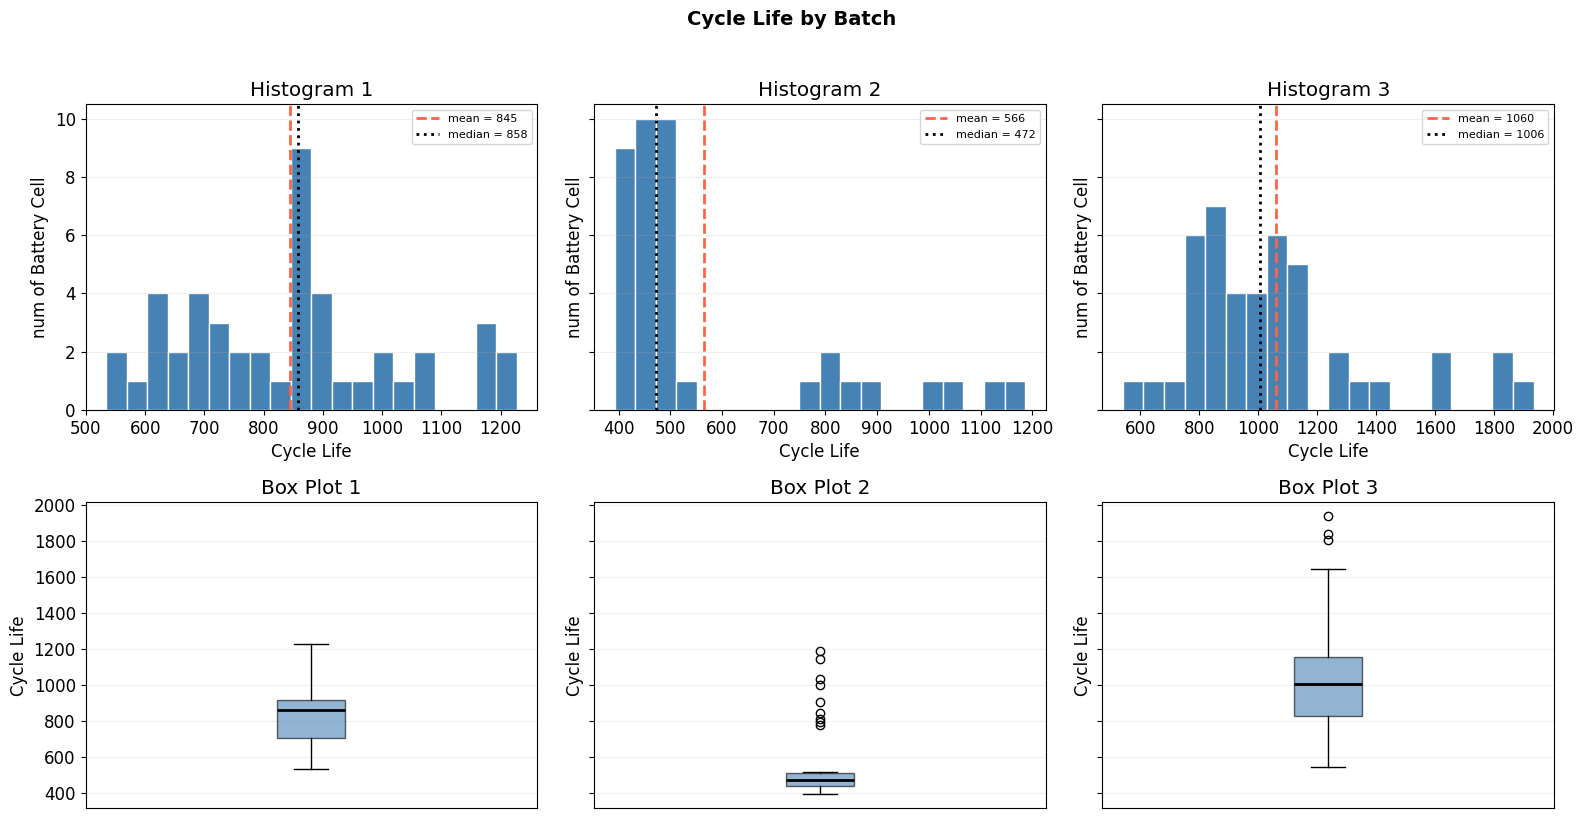

[Batch 1: batch1]
count      46.0
mean      844.7
std       184.6
min       534.0
25%       703.2
50%       858.5
75%       914.2
max      1227.0
Name: cycle_life, dtype: float64

[Batch 2: batch2]
count      39.0
mean      565.7
std       222.2
min       392.0
25%       439.5
50%       472.0
75%       508.5
max      1186.0
Name: cycle_life, dtype: float64

[Batch 3: batch3]
count      44.0
mean     1059.7
std       313.9
min       541.0
25%       828.0
50%      1005.5
75%      1155.2
max      1935.0
Name: cycle_life, dtype: float64



In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False, sharey='row')
plot_color = 'steelblue'

for col, (name, obj) in enumerate(batches.items(), start=1):
    cycle_life_df = obj['cycle_life_df'][['cell_id', 'cycle_life', 'charging_policy']].copy()
    mean_life = cycle_life_df['cycle_life'].mean()
    median_life = cycle_life_df['cycle_life'].median()

    axes[0, col - 1].hist(
        cycle_life_df['cycle_life'],
        bins=20,
        color=plot_color,
        edgecolor='white'
    )
    axes[0, col - 1].set_title(f'Histogram {col}')
    axes[0, col - 1].set_xlabel('Cycle Life')
    axes[0, col - 1].set_ylabel('num of Battery Cell')
    axes[0, col - 1].axvline(mean_life, color='tomato', linestyle='--', linewidth=2, label=f'mean = {mean_life:.0f}')
    axes[0, col - 1].axvline(median_life, color='black', linestyle=':', linewidth=2, label=f'median = {median_life:.0f}')
    axes[0, col - 1].legend(fontsize=8)
    axes[0, col - 1].grid(axis='y', alpha=0.2)

    axes[1, col - 1].boxplot(
        cycle_life_df['cycle_life'],
        patch_artist=True,
        boxprops=dict(facecolor=plot_color, alpha=0.6),
        medianprops=dict(color='black', linewidth=2),
    )
    axes[1, col - 1].set_title(f'Box Plot {col}')
    axes[1, col - 1].set_ylabel('Cycle Life')
    axes[1, col - 1].set_xticks([])
    axes[1, col - 1].grid(axis='y', alpha=0.2)

plt.suptitle('Cycle Life by Batch', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

for col, (name, obj) in enumerate(batches.items(), start=1):
    cycle_life_df = obj['cycle_life_df'][['cell_id', 'cycle_life', 'charging_policy']].copy()
    print(f'[Batch {col}: {name}]')
    print(cycle_life_df['cycle_life'].describe().round(1))
    print()


**그림 1. Batch별 Cycle Life Histogram과 Box Plot**

위 행은 `Histogram 1, 2, 3`, 아래 행은 `Box Plot 1, 2, 3`으로 배치해 각 batch의 `cycle_life` 분포를 비교한 그림입니다. Histogram은 전체 분포 모양과 평균/중앙값 위치를 보여 주고, Box Plot은 중심과 퍼짐, 분포 차이를 요약해 보여 줍니다.


[analysis]
- `batch2`는 histogram과 box plot 모두 낮은 cycle 구간에 집중되어 있어 단수명 분포가 가장 강하게 나타납니다.
- `batch3`는 평균과 중앙값이 모두 더 높은 위치에 있고 분포 전체도 상위 cycle 영역에 형성되어, 장수명 batch라는 점이 분명합니다.
- `batch1`은 두 batch 사이의 중간적인 위치를 보이며, 세 batch의 중심과 spread가 서로 다르다는 점에서 뚜렷한 `batch shift`가 확인됩니다.
- 즉 1.1에서는 batch마다 수명 분포 자체가 다르다는 점을 먼저 확인할 수 있습니다. 다음 1.2에서는 이 차이를 장수명/단수명 비율로 더 직접적으로 요약합니다.


### 1.2 장수명(>1,000)/단수명(<500) 비율 확인


In [12]:
rows = []
for name, obj in batches.items():
    life = obj['cycle_life_df']['cycle_life']
    rows.append({
        'batch': name,
        'n_cells': len(life),
        'life_min': life.min(),
        'life_max': life.max(),
        'life_mean': life.mean(),
        'life_median': life.median(),
        'long_ratio_pct': (life > 1000).mean() * 100,
        'short_ratio_pct': (life < 500).mean() * 100,
    })
life_compare = pd.DataFrame(rows).set_index('batch').round(2)
life_compare


,n_cells,life_min,life_max,life_mean,life_median,long_ratio_pct,short_ratio_pct
batch,,,,,,,
batch1,46,534,1227,844.72,858.5,21.74,0.00
batch2,39,392,1186,565.74,472.0,7.69,71.79
batch3,44,541,1935,1059.66,1005.5,52.27,0.00


**표 1. Batch별 Cycle Life 요약 통계**

각 batch의 셀 수, 수명 범위, 평균/중앙값, 장수명 비율(`>1000`), 단수명 비율(`<500`)을 정리한 표입니다.


[analysis]
- 장수명 비율(`>1000`)은 `batch3`에서 가장 높고, 단수명 비율(`<500`)은 `batch2`에서 가장 높습니다.
- 따라서 1.1에서 보인 분포 차이는 단순한 시각적 인상이 아니라, 비율 기준으로도 뚜렷하게 확인됩니다.
- 이런 차이는 이후 열화 곡선과 조기 열화 feature를 해석할 때 batch를 분리해서 볼 필요가 있다는 점을 시사합니다.

[modeling implication]
- batch별 target 분포가 다르므로 random split만으로 평가하기보다, batch 차이를 고려한 검증 전략이 필요합니다.


### 1.3 이상치 셀 식별 - 왜 유독 짧은가?


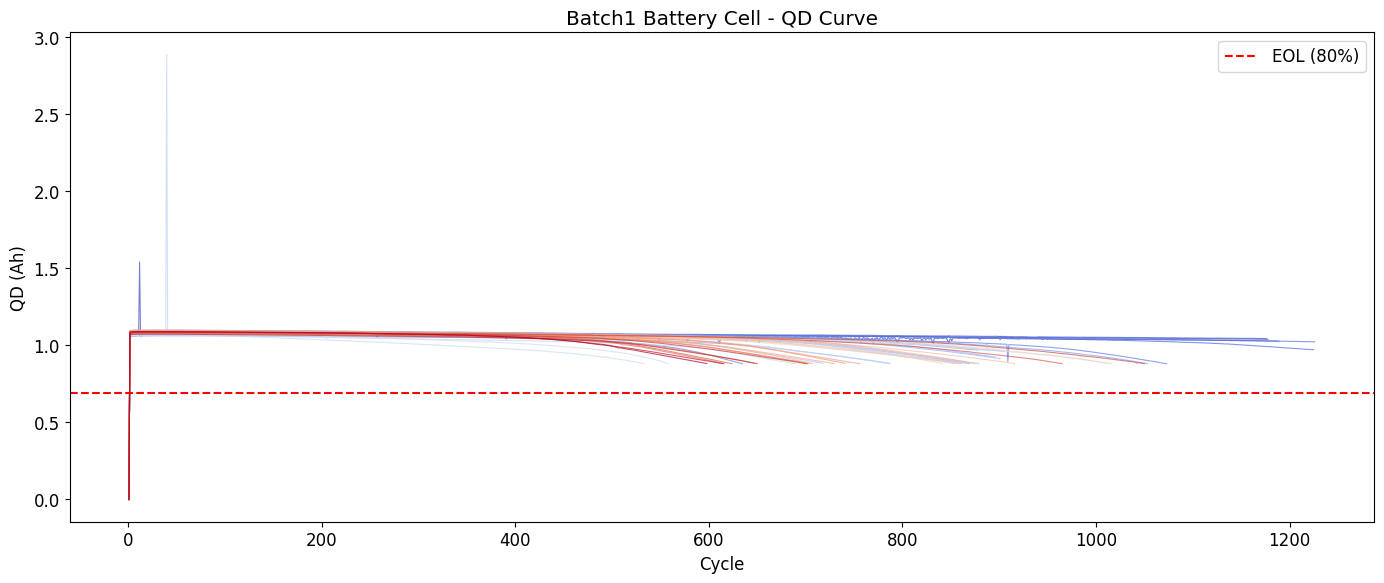

In [13]:
batch1_df = batches['batch1']['df'].copy()
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = batch1_df['cell_id'].unique()
colors = plt.cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = batch1_df[batch1_df['cell_id'] == cid].sort_values('cycle')
    ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

nominal = batch1_df[batch1_df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
ax.axhline(
    y=0.8 * nominal,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='EOL (80%)'
)
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Batch1 Battery Cell - QD Curve')
ax.legend()
plt.tight_layout()
plt.show()


**그림 1-1. Batch1 Battery Cell QD Curve**

`batch1`의 모든 셀에 대한 `QD` 곡선을 한 그림에 그린 결과입니다. 빨간 점선은 공칭 용량의 80%에 해당하는 `EOL (80%)` 기준선을 나타냅니다.


[plot]
- 대부분의 셀은 비슷한 초기 용량에서 시작한 뒤 cycle이 증가할수록 완만하게 감소하며, 전형적인 capacity fade 곡선 형태를 보입니다.
- 일부 셀은 더 이른 시점에 `EOL (80%)` 기준선에 가까워지거나 더 빠르게 내려가며, 이런 셀들이 상대적으로 짧은 수명군으로 해석됩니다.
- 곡선 전체를 함께 보면 `batch1` 내부에서도 열화 속도 차이가 존재하며, 동일한 초기 용량으로 시작하더라도 이후 fade trajectory는 셀마다 다르게 전개됩니다.
- 즉 1.3에서는 수명 분포 차이가 실제 열화 곡선 형태 차이로 이어진다는 점을 확인할 수 있습니다.

[modeling implication]
- 따라서 단일 시점의 용량값보다, cycle에 따른 전체 fade pattern과 EOL 도달 속도를 함께 반영하는 feature가 더 유용할 수 있습니다.
- 이후 2장에서는 이 fade trajectory가 어떤 속도로 감소하고, 중간 이후 가속되는지를 더 구체적으로 확인합니다.


## 2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?


### 2.1 사이클 별 Qd 추이 시각화


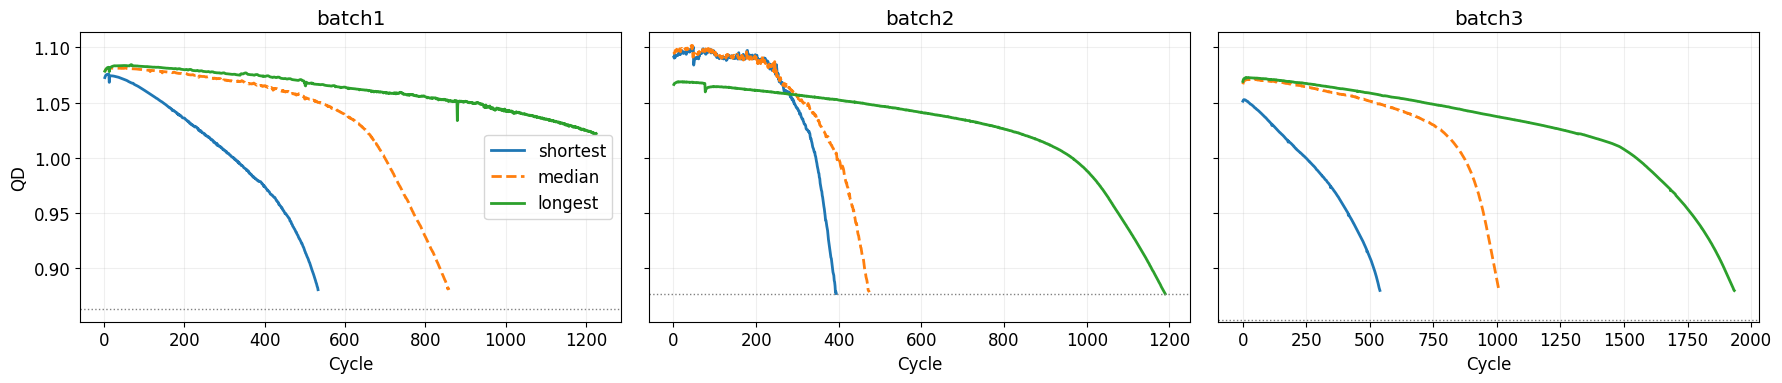

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, (name, obj) in zip(axes, batches.items()):
    cycle_life_df = obj['cycle_life_df']
    df_clean = obj['df_clean']
    nominal_qd = obj['nominal_qd']
    short_id = int(cycle_life_df.loc[cycle_life_df['cycle_life'].idxmin(), 'cell_id'])
    median_id = int(cycle_life_df.iloc[len(cycle_life_df) // 2]['cell_id'])
    long_id = int(cycle_life_df.loc[cycle_life_df['cycle_life'].idxmax(), 'cell_id'])
    for cid, label, style in [(short_id, 'shortest', '-'), (median_id, 'median', '--'), (long_id, 'longest', '-')]:
        sub = df_clean[df_clean['cell_id'] == cid].sort_values('cycle')
        ax.plot(sub['cycle'], sub['QD'], linestyle=style, linewidth=2, label=label)
    ax.axhline(nominal_qd * 0.8, color='gray', linestyle=':', linewidth=1)
    ax.set_title(name)
    ax.set_xlabel('Cycle')
    ax.grid(alpha=0.2)
axes[0].set_ylabel('QD')
axes[0].legend()
plt.tight_layout()
plt.show()


**그림 2. Batch별 대표 QD Fade Curve 비교**

각 batch에서 shortest, median, longest 수명 셀의 `QD` 감소 곡선을 비교한 그림입니다.


[analysis]
- 대표 `QD` fade curve를 보면 `batch2`는 더 이른 cycle에서 감소가 시작되고, `batch3`는 더 오랫동안 높은 용량을 유지합니다. `batch1`은 두 batch 사이의 중간적인 패턴을 보입니다.
- 즉 2.1에서는 batch마다 열화 trajectory의 전체 모양이 다르다는 점을 먼저 확인할 수 있습니다. 다음 2.2에서는 이 감소가 단순한 선형 하락인지, 아니면 시간이 지나며 더 빨라지는지를 기울기 관점에서 확인합니다.


### 2.2 열화 속도가 일정한가, 가속되는가?


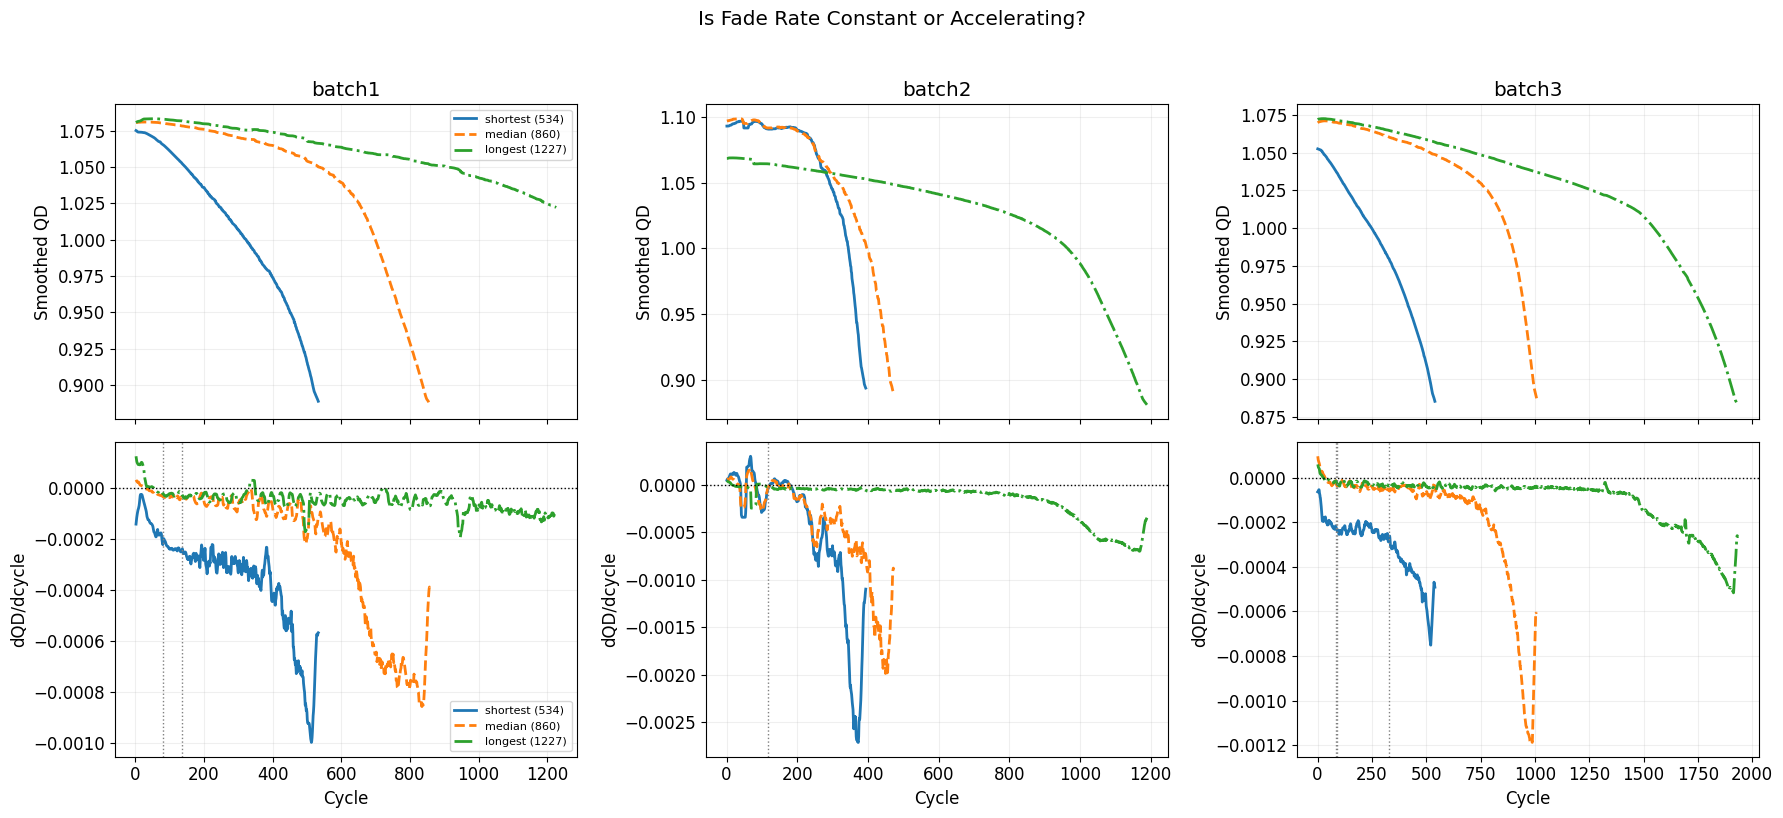

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex='col')
line_styles = [('shortest', '-'), ('median', '--'), ('longest', '-.')]

for col, (name, obj) in enumerate(batches.items()):
    cycle_life_df = obj['cycle_life_df']
    df_clean = obj['df_clean']
    knee_summary = obj['knee_summary']

    representative_ids = {
        'shortest': int(cycle_life_df.loc[cycle_life_df['cycle_life'].idxmin(), 'cell_id']),
        'median': int(cycle_life_df.iloc[len(cycle_life_df) // 2]['cell_id']),
        'longest': int(cycle_life_df.loc[cycle_life_df['cycle_life'].idxmax(), 'cell_id']),
    }

    for label, style in line_styles:
        cid = representative_ids[label]
        sub = df_clean[df_clean['cell_id'] == cid].sort_values('cycle').copy()
        smooth_qd = (
            sub['QD']
            .rolling(window=25, center=True, min_periods=8)
            .median()
            .bfill()
            .ffill()
        )
        fade_rate = pd.Series(
            np.gradient(smooth_qd.to_numpy(), sub['cycle'].to_numpy()),
            index=sub.index,
        ).rolling(window=15, center=True, min_periods=5).mean().bfill().ffill()

        life = int(sub['cycle_life'].iloc[0])
        axes[0, col].plot(sub['cycle'], smooth_qd, linestyle=style, linewidth=2, label=f'{label} ({life})')
        axes[1, col].plot(sub['cycle'], fade_rate, linestyle=style, linewidth=2, label=f'{label} ({life})')

        knee_row = knee_summary[knee_summary['cell_id'] == cid]
        if not knee_row.empty and pd.notna(knee_row['knee_cycle'].iloc[0]):
            knee_cycle = float(knee_row['knee_cycle'].iloc[0])
            axes[1, col].axvline(knee_cycle, color='gray', linestyle=':', linewidth=1)

    axes[0, col].set_title(name)
    axes[0, col].set_ylabel('Smoothed QD')
    axes[0, col].grid(alpha=0.2)
    axes[1, col].axhline(0, color='black', linestyle=':', linewidth=1)
    axes[1, col].set_xlabel('Cycle')
    axes[1, col].set_ylabel('dQD/dcycle')
    axes[1, col].grid(alpha=0.2)

axes[0, 0].legend(fontsize=8)
axes[1, 0].legend(fontsize=8)
plt.suptitle('Is Fade Rate Constant or Accelerating?', y=1.02)
plt.tight_layout()
plt.show()


**그림 2-1. 대표 셀의 QD 곡선과 열화 속도(dQD/dcycle) 비교**

위쪽은 smoothed `QD` 곡선, 아래쪽은 그 기울기인 `dQD/dcycle`입니다. 아래 곡선이 더 음의 방향으로 내려갈수록 열화 속도가 가속되는 것으로 해석할 수 있습니다.


[analysis]
- 아래쪽 `dQD/dcycle` 곡선이 시간이 지나도 거의 일정하면 열화 속도가 일정한 것이고, cycle이 진행될수록 더 음의 방향으로 내려가면 열화가 가속된다고 볼 수 있습니다.
- 이 그림에서는 특히 짧은 수명 셀에서 후반부로 갈수록 기울기가 더 가팔라지는 구간이 나타나, 많은 셀에서 열화 속도가 일정하기보다 중간 이후 가속되는 패턴이 관찰됩니다.
- `batch2`는 이런 가속 구간이 더 이르고 급하게 나타나는 편이고, `batch3`는 상대적으로 완만하게 진행되다가 늦은 시점에 가속되는 경향을 보입니다. `batch1`은 그 사이의 중간적인 패턴입니다.
- 따라서 2.2의 핵심은 “가속이 존재하는가”를 확인하는 것입니다. 이어지는 2.3에서는 이 가속이 시작되는 시점을 `knee point`로 정량화해 비교합니다.

[modeling implication]
- 따라서 열화를 단일 선형 감소로 가정하기보다, 초기 기울기와 후반 기울기의 차이 또는 `fade_acceleration_ratio` 같은 가속 지표를 함께 보는 것이 더 적절합니다.
- 모델링에서는 `baseline_fade_rate`, `post_knee_fade_rate`, `fade_acceleration_ratio`, `knee_cycle`처럼 시간에 따른 slope 변화 정보를 담는 feature를 유지하는 것이 좋습니다.


### 2.3 Knee point - 급격한 열화 시작점 탐색


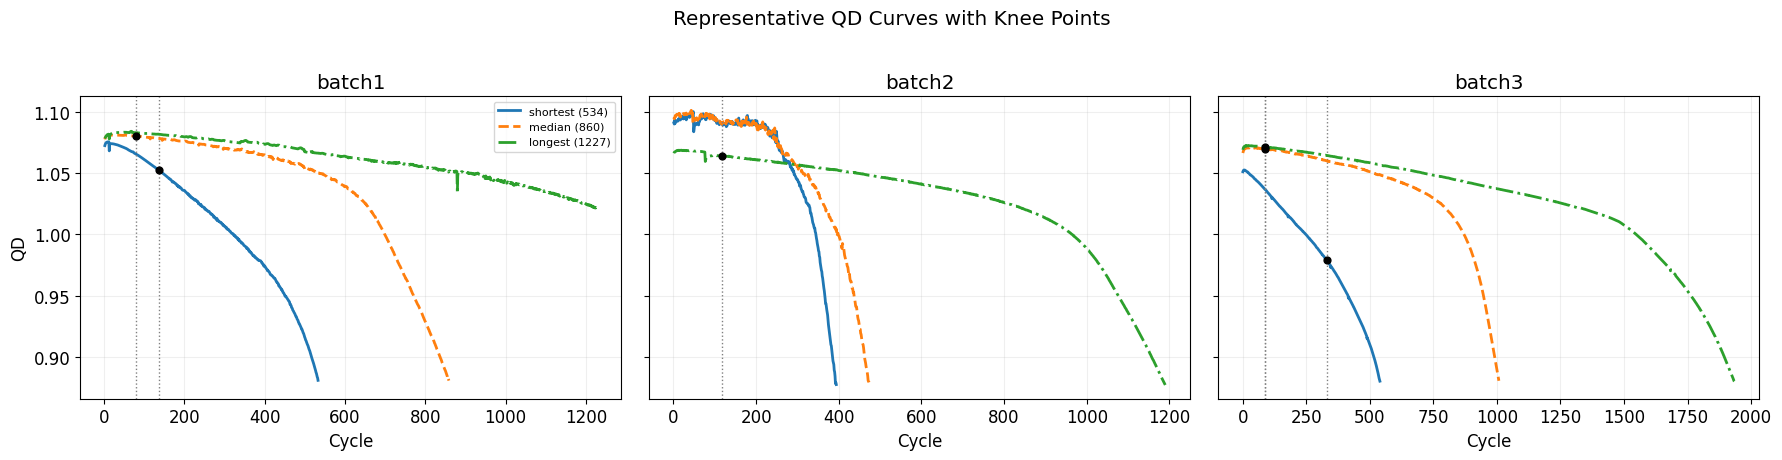

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
line_styles = [('shortest', '-'), ('median', '--'), ('longest', '-.')]

for ax, (name, obj) in zip(axes, batches.items()):
    cycle_life_df = obj['cycle_life_df']
    df_clean = obj['df_clean']
    knee_summary = obj['knee_summary']

    representative_ids = {
        'shortest': int(cycle_life_df.loc[cycle_life_df['cycle_life'].idxmin(), 'cell_id']),
        'median': int(cycle_life_df.iloc[len(cycle_life_df) // 2]['cell_id']),
        'longest': int(cycle_life_df.loc[cycle_life_df['cycle_life'].idxmax(), 'cell_id']),
    }

    for label, style in line_styles:
        cid = representative_ids[label]
        sub = df_clean[df_clean['cell_id'] == cid].sort_values('cycle')
        if sub.empty:
            continue
        life = int(sub['cycle_life'].iloc[0])
        ax.plot(sub['cycle'], sub['QD'], linestyle=style, linewidth=2, label=f'{label} ({life})')

        knee_row = knee_summary[knee_summary['cell_id'] == cid]
        if not knee_row.empty and pd.notna(knee_row['knee_cycle'].iloc[0]):
            knee_cycle = float(knee_row['knee_cycle'].iloc[0])
            knee_sub = sub.iloc[(sub['cycle'] - knee_cycle).abs().argsort()[:1]]
            ax.axvline(knee_cycle, color='gray', linestyle=':', linewidth=1)
            ax.scatter(knee_sub['cycle'], knee_sub['QD'], color='black', s=24, zorder=3)

    ax.set_title(name)
    ax.set_xlabel('Cycle')
    ax.grid(alpha=0.2)

axes[0].set_ylabel('QD')
axes[0].legend(fontsize=8)
plt.suptitle('Representative QD Curves with Knee Points', y=1.02)
plt.tight_layout()
plt.show()


**그림 2-2. 대표 셀 QD 곡선의 Knee Point 표시**

각 batch의 shortest, median, longest 수명 셀에 대해 `QD` 곡선을 그리고, 탐지된 `knee_cycle` 위치를 점선과 점으로 표시했습니다.


In [17]:
knee_rows = []
for name, obj in batches.items():
    knee_summary = obj['knee_summary'].copy()
    valid = knee_summary.dropna(subset=['knee_cycle'])
    knee_rows.append({
        'batch': name,
        'nominal_qd': round(float(obj['nominal_qd']), 3),
        'cells_with_knee': int(valid['cell_id'].nunique()),
        'earliest_knee_cycle': float(valid['knee_cycle'].min()) if not valid.empty else np.nan,
        'median_knee_cycle': float(valid['knee_cycle'].median()) if not valid.empty else np.nan,
        'mean_fade_acceleration_ratio': float(valid['fade_acceleration_ratio'].mean()) if not valid.empty else np.nan,
    })

knee_compare = pd.DataFrame(knee_rows).set_index('batch').round(2)
knee_compare


,nominal_qd,cells_with_knee,earliest_knee_cycle,median_knee_cycle,mean_fade_acceleration_ratio
batch,,,,,
batch1,1.08,37,80.0,80.0,3.28
batch2,1.10,5,80.0,84.0,4.77
batch3,1.07,44,80.0,81.0,3.79


**표 2. Knee Point 및 열화 가속 요약**

공칭 방전용량, knee가 검출된 셀 수, 가장 이른 knee cycle, 평균 열화 가속도를 비교한 표입니다.


[analysis]
- 2.3에서는 2.2에서 확인한 가속 패턴을 하나의 시점으로 요약하기 위해, 열화가 급격히 빨라지기 시작하는 cycle을 `knee_cycle`로 정의해 비교합니다.
- 탐지 방식은 `QD` 곡선을 rolling median으로 smoothing한 뒤 `dQD/dcycle` 기울기를 계산하고, 초기 구간(`cycle 10~100`)의 baseline slope보다 약 2배 이상 더 가팔라지는 첫 시점을 knee로 정의하는 방식입니다.
- 또한 너무 이른 noise를 피하기 위해 `cycle 80` 이후부터만 knee를 탐색했습니다. 즉 이 knee point는 시각적으로 임의 선택한 점이 아니라, 초기 대비 열화 속도 가속을 기준으로 정량적으로 찾은 전환점입니다.
- 대표 셀 곡선에서도 knee가 검출된 경우에는 완만하게 감소하던 `QD`가 특정 시점 이후 더 빠르게 떨어지기 시작하는 전환점이 보입니다. 즉 knee point는 2.2의 “가속되는 구간”을 더 간결하게 표현한 지표로 해석할 수 있습니다.
- 요약표를 보면 `batch1`과 `batch3`는 knee가 검출되는 셀이 비교적 많아 전환점 기반 해석이 가능하지만, `batch2`는 knee 검출 셀 수가 적어 전환 시점이 더 불안정하거나 덜 뚜렷하게 나타나는 편입니다.

[modeling implication]
- 따라서 `knee_cycle`은 의미 있는 feature지만, 모든 셀에서 안정적으로 잡히는 값은 아니므로 단독 사용보다는 `baseline_fade_rate`, `post_knee_fade_rate`, `fade_acceleration_ratio`와 함께 해석하는 것이 안전합니다.
- 특히 batch 간 검출 안정성이 다르기 때문에, knee 관련 변수는 batch-aware validation 하에서 유효성을 점검하는 것이 좋습니다.


## 3. ΔQ(V) 곡선 - 초기 사이클에서 차이가 보이는가?


### 3.1 사이클 100번 - 사이클 10번의 Q(V) 차이 계산


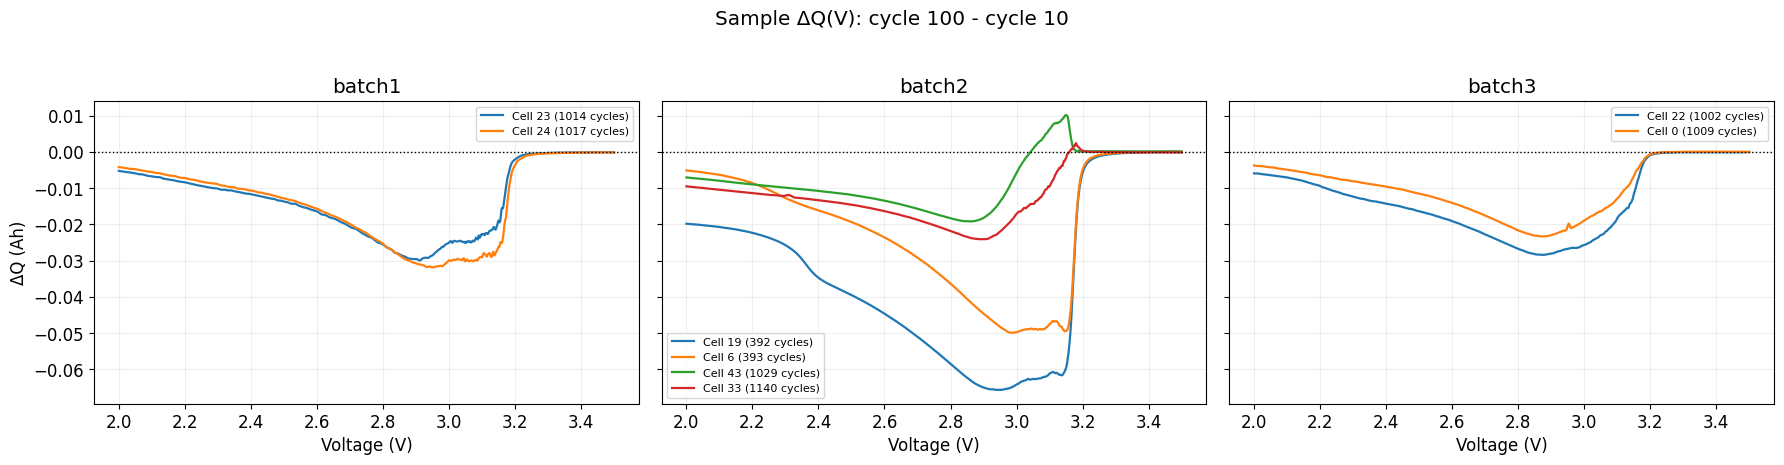

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
for ax, (name, obj) in zip(axes, batches.items()):
    cycle_life_df = obj['cycle_life_df'].sort_values('cycle_life').reset_index(drop=True)
    batch = obj['batch']

    short_ids = cycle_life_df.loc[cycle_life_df['cycle_life'] < 500, 'cell_id'].tolist()[:2]
    long_ids = cycle_life_df.loc[cycle_life_df['cycle_life'] > 1000, 'cell_id'].tolist()[:2]
    sample_ids = short_ids + long_ids

    for cid in sample_ids:
        profile = get_delta_q_profile(batch[int(cid)])
        if profile is None:
            continue
        life = int(cycle_life_df.loc[cycle_life_df['cell_id'] == cid, 'cycle_life'].iloc[0])
        ax.plot(
            profile['voltage'],
            profile['delta_q'],
            linewidth=1.6,
            label=f'Cell {cid} ({life} cycles)'
        )

    ax.axhline(0, color='black', linestyle=':', linewidth=1)
    ax.set_title(name)
    ax.set_xlabel('Voltage (V)')
    ax.grid(alpha=0.2)
    if sample_ids:
        ax.legend(fontsize=8)

axes[0].set_ylabel('ΔQ (Ah)')
plt.suptitle('Sample ΔQ(V): cycle 100 - cycle 10', y=1.03)
plt.tight_layout()
plt.show()


**그림 3. Batch별 샘플 ΔQ(V) 곡선**

각 batch에서 일부 장수명/단수명 셀을 골라 `cycle 100 - cycle 10`의 `Q(V)` 차이를 직접 그린 그림입니다.


[analysis]
- `cycle 100 - cycle 10` 차이를 직접 그려 보면, 같은 batch 안에서도 셀별 `ΔQ(V)` 곡선의 폭과 형태가 분명히 다릅니다. 즉 초기 100사이클 안에서 이미 열화 패턴 차이가 전압 구간별로 나타나기 시작합니다.
- 특히 단수명으로 이어지는 셀일수록 곡선의 진폭이 더 크고, 특정 전압 구간에서 음의 방향 변화가 더 깊게 나타나는 경향이 보입니다. 반대로 장수명 셀은 전체적으로 더 완만하고 안정적인 형태를 유지합니다.
- 세 batch 모두에서 이런 형상 차이가 반복된다는 점은, 초기 capacity shift가 단순 노이즈가 아니라 이후 수명 차이와 연결되는 조기 열화 신호일 가능성이 높다는 뜻입니다.

[modeling implication]
- 따라서 3.1의 핵심은 `ΔQ(V)` 곡선 자체가 유의미한 early degradation signature라는 점입니다. 모델 입력에는 단일 cycle 요약값보다 이런 전압-용량 형상 변화를 반영한 feature가 우선 포함되어야 합니다.
- 실무적으로는 곡선 전체를 그대로 쓰기보다, 이후 3.3에서 정리할 `delta_q_std`, `delta_q_range`, 전압 구간 평균값 같은 통계량으로 압축해 사용하는 것이 해석성과 안정성 측면에서 더 적절합니다.


### 3.2 장수명 셀 vs 단수명 셀의 ΔQ 형태 비교


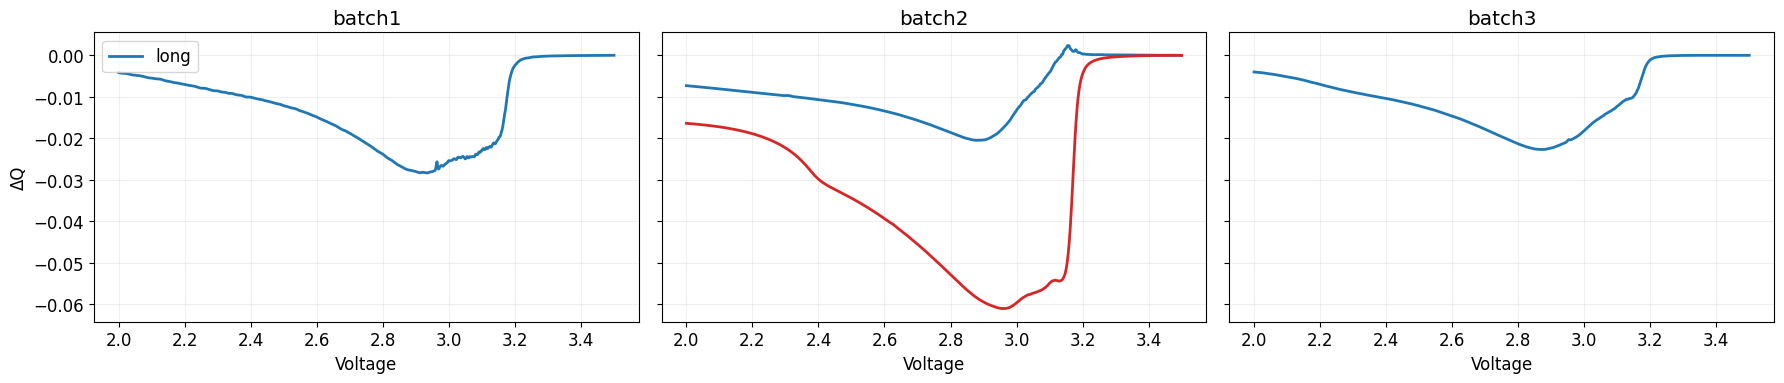

In [19]:
def get_delta_q_profile(cell, cycle_a=10, cycle_b=100):
    cycles = get_cell_cycles(cell)
    if len(cycles) < cycle_b:
        return None
    try:
        q_a = to_float_array(cycles[cycle_a - 1]['Qdlin'])
        q_b = to_float_array(cycles[cycle_b - 1]['Qdlin'])
    except KeyError:
        return None
    v = to_float_array(cell.get('Vdlin', np.linspace(2.0, 3.5, min(len(q_a), len(q_b)))))
    m = min(len(v), len(q_a), len(q_b))
    return pd.DataFrame({'voltage': v[:m], 'delta_q': q_b[:m] - q_a[:m]})

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, (name, obj) in zip(axes, batches.items()):
    life = obj['cycle_life_df']
    batch = obj['batch']
    long_ids = life.loc[life['cycle_life'] > 1000, 'cell_id'].tolist()[:5]
    short_ids = life.loc[life['cycle_life'] < 500, 'cell_id'].tolist()[:5]
    profiles = []
    for label, ids, color in [('long', long_ids, '#1f77b4'), ('short', short_ids, '#d62728')]:
        curves = []
        for cid in ids:
            prof = get_delta_q_profile(batch[int(cid)])
            if prof is not None:
                curves.append(prof['delta_q'].to_numpy())
                voltage = prof['voltage'].to_numpy()
        if curves:
            m = min(len(x) for x in curves)
            mean_curve = np.mean([x[:m] for x in curves], axis=0)
            ax.plot(voltage[:m], mean_curve, color=color, linewidth=2, label=label)
    ax.set_title(name)
    ax.set_xlabel('Voltage')
    ax.grid(alpha=0.2)
axes[0].set_ylabel('ΔQ')
axes[0].legend()
plt.tight_layout()
plt.show()


**그림 3-2. 장수명 vs 단수명 셀의 평균 ΔQ(V) 곡선**

각 batch에서 장수명 셀과 단수명 셀의 평균 `ΔQ(V)` 곡선을 비교한 그림입니다.


[analysis]
- 단수명 셀은 전압 구간 전반에서 더 큰 변화폭을 보이고, 장수명 셀은 상대적으로 완만한 `ΔQ(V)` 형태를 유지합니다.
- 특히 `batch2`에서 장단수명 차이가 가장 직접적으로 드러납니다.

[modeling implication]
- `ΔQ(V)`는 조기 risk score 성격의 feature block으로 활용할 수 있습니다.


### 3.3 이를 구분할 수 있는 통계값으로 피쳐 추출


In [20]:
delta_compare = {}
for name, obj in batches.items():
    delta = obj['delta_q'].copy()
    numeric_cols = [
        'delta_q_std', 'delta_q_range', 'delta_q_min', 'delta_q_midV_mean', 'delta_q_highV_mean'
    ]
    corr = (
        delta[['cycle_life'] + numeric_cols]
        .corr(numeric_only=True)['cycle_life']
        .drop('cycle_life')
        .dropna()
    )
    delta_compare[name] = corr.to_dict()

delta_feature_summary = pd.DataFrame({
    'feature': ['delta_q_std', 'delta_q_range', 'delta_q_min', 'delta_q_midV_mean', 'delta_q_highV_mean'],
    'meaning': [
        'ΔQ(V) 전체 변동성',
        'ΔQ(V) 최대-최소 범위',
        'ΔQ(V) 최솟값',
        '중간 전압 구간 평균 ΔQ',
        '고전압 구간 평균 ΔQ',
    ],
    'batch1_corr': [delta_compare['batch1'].get('delta_q_std'), delta_compare['batch1'].get('delta_q_range'), delta_compare['batch1'].get('delta_q_min'), delta_compare['batch1'].get('delta_q_midV_mean'), delta_compare['batch1'].get('delta_q_highV_mean')],
    'batch2_corr': [delta_compare['batch2'].get('delta_q_std'), delta_compare['batch2'].get('delta_q_range'), delta_compare['batch2'].get('delta_q_min'), delta_compare['batch2'].get('delta_q_midV_mean'), delta_compare['batch2'].get('delta_q_highV_mean')],
    'batch3_corr': [delta_compare['batch3'].get('delta_q_std'), delta_compare['batch3'].get('delta_q_range'), delta_compare['batch3'].get('delta_q_min'), delta_compare['batch3'].get('delta_q_midV_mean'), delta_compare['batch3'].get('delta_q_highV_mean')],
}).round(3)
delta_feature_summary


,feature,meaning,batch1_corr,batch2_corr,batch3_corr
0,delta_q_std,ΔQ(V) 전체 변동성,-0.894,-0.835,-0.673
1,delta_q_range,ΔQ(V) 최대-최소 범위,-0.882,-0.802,-0.601
2,delta_q_min,ΔQ(V) 최솟값,0.882,0.819,0.692
3,delta_q_midV_mean,중간 전압 구간 평균 ΔQ,0.881,0.819,0.664
4,delta_q_highV_mean,고전압 구간 평균 ΔQ,0.804,0.791,0.669


**표 3-1. ΔQ(V) 기반 후보 feature 요약**

`ΔQ(V)` 곡선에서 추출한 핵심 통계 feature와 각 batch에서의 상관 방향을 정리한 표입니다.


[analysis]
- `delta_q_std`, `delta_q_range`, `delta_q_min`, `delta_q_midV_mean`, `delta_q_highV_mean` 같은 요약 통계값으로 `ΔQ(V)` 곡선을 압축할 수 있습니다.
- 이 통계값들은 세 batch 모두에서 `cycle_life`와 강한 상관을 보이며, 특히 `delta_q_std`와 `delta_q_min`이 가장 일관된 신호를 보입니다.

[modeling implication]
- `ΔQ(V)` 통계 feature는 feature engineering의 1순위 블록으로 두는 것이 적절합니다.


## 4. 충전 조건 (C-rate)과 수명의 관계는?


### 4.1 충전 프로토콜별 평균 수명 비교


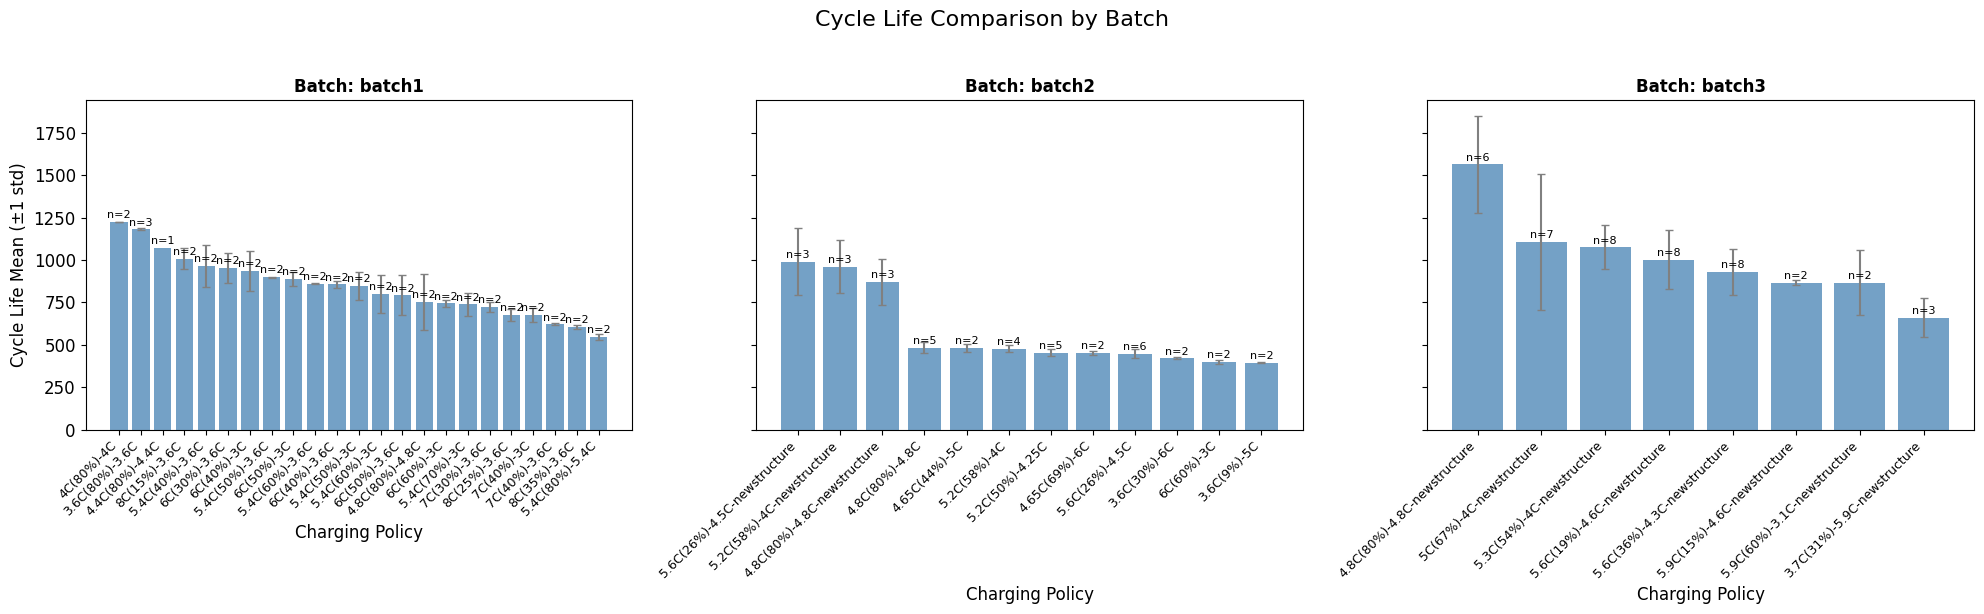


 [통합 Charging Policy 비교 테이블] 


,mean,std,count,min,max
charging_policy,,,,,
4.8C(80%)-4.8C-newstructure,1333.333333,419.067417,9,777,1836
4C(80%)-4C,1226.500000,0.707107,2,1226,1227
3.6C(80%)-3.6C,1182.000000,7.000000,3,1177,1190
5C(67%)-4C-newstructure,1105.714286,402.911783,7,813,1935
5.3C(54%)-4C-newstructure,1074.375000,129.674248,8,935,1315
4.4C(80%)-4.4C,1074.000000,nan,1,1074,1074
8C(15%)-3.6C,1008.500000,60.104076,2,966,1051
5.6C(19%)-4.6C-newstructure,1001.375000,174.555712,8,796,1267
5.6C(26%)-4.5C-newstructure,991.333333,197.560961,3,791,1186


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 시각화 설정 (1x3 Subplots)
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
batch_names = list(batches.keys())  # ['batch1', 'batch2', 'batch3']

all_data_for_table = []

for i, name in enumerate(batch_names):
    ax = axes[i]
    
    # 해당 배치의 cycle_life_df 추출
    df_batch = batches[name]['cycle_life_df']
    all_data_for_table.append(df_batch) # 통합 테이블용 리스트에 추가
    
    # 데이터 집계
    policy_life = df_batch.groupby('charging_policy')['cycle_life'].agg(['mean', 'std', 'count'])
    policy_life = policy_life.sort_values('mean', ascending=False)
    
    # 막대 그래프 그리기
    x = range(len(policy_life))
    bars = ax.bar(x, policy_life['mean'],
                  yerr=policy_life['std'],
                  color='steelblue', alpha=0.75,
                  error_kw=dict(ecolor='gray', capsize=3))
    
    # 서브플롯 디테일 설정
    ax.set_xticks(x)
    ax.set_xticklabels(policy_life.index, rotation=45, ha='right', fontsize=9)
    ax.set_title(f'Batch: {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Charging Policy')
    if i == 0:
        ax.set_ylabel('Cycle Life Mean (±1 std)')

    # 막대 위에 n수 표시
    for bar, (_, row) in zip(bars, policy_life.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Cycle Life Comparison by Batch', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 2. 통합 policy_compare 테이블 생성
# 모든 배치의 데이터를 하나로 합칩니다.
total_cycle_df = pd.concat(all_data_for_table, ignore_index=True)

policy_compare = total_cycle_df.groupby('charging_policy')['cycle_life'].agg(
    ['mean', 'std', 'count', 'min', 'max']
).sort_values('mean', ascending=False)

print("\n" + "="*50)
print(" [통합 Charging Policy 비교 테이블] ")
print("="*50)
display(policy_compare.style.background_gradient(subset=['mean'], cmap='Blues'))

### 4.2 고속 충전 셀이 정말 수명이 짧은가?


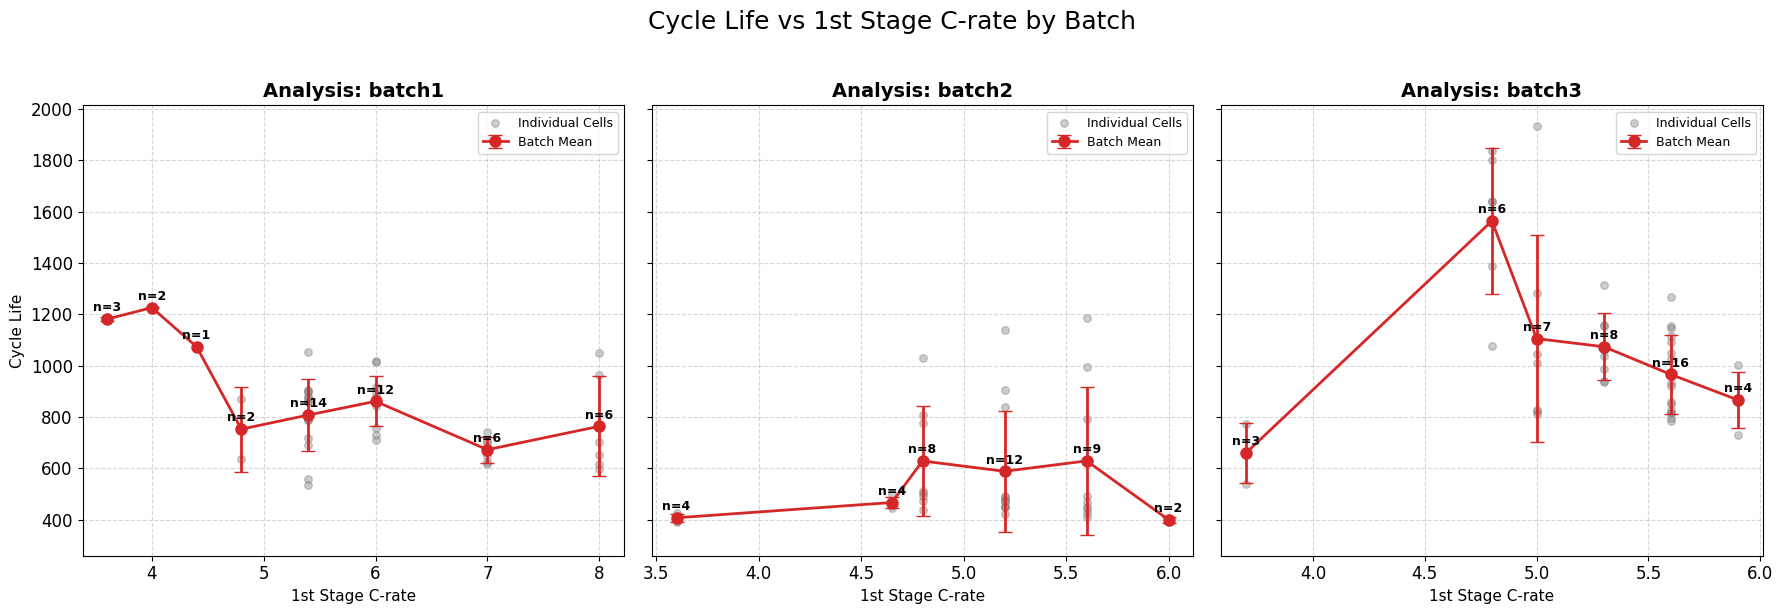


                       [전체 통합 요약]                       
            mean    std  count
stage1_c                      
3.60       739.6  414.0      7
3.70       660.0  115.7      3
4.00      1226.5    0.7      2
4.40      1074.0    NaN      1
4.65       467.2   23.1      4
4.80       995.2  509.3     16
5.00      1105.7  402.9      7
5.20       588.8  235.4     12
5.30      1074.4  129.7      8
5.40       808.3  141.9     14
5.60       844.9  265.0     25
5.90       866.8  110.9      4
6.00       795.6  189.8     14
7.00       673.2   50.4      6
8.00       764.2  194.4      6


In [29]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 설정 및 데이터 파싱 준비
batch_names = list(batches.keys())
pattern = r'([0-9.]+)C\(([0-9]+)%\)-([0-9.]+)C'

# 그래프 크기를 가로로 대폭 늘림 (18x6)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

all_parsed_data = []

for i, name in enumerate(batch_names):
    if i >= 3: break
    ax = axes[i]
    
    # 데이터 추출 및 C-rate 분리
    df_curr = batches[name]['cycle_life_df'].copy()
    parsed = df_curr['charging_policy'].str.extract(pattern)
    parsed.columns = ['stage1_c', 'switch_pct', 'stage2_c']
    df_curr[['stage1_c', 'switch_pct', 'stage2_c']] = parsed.astype(float)
    
    # 통합용 저장
    df_curr['batch_name'] = name
    all_parsed_data.append(df_curr)
    
    # 통계 계산
    st1_sum = df_curr.groupby('stage1_c')['cycle_life'].agg(['mean', 'std', 'count']).sort_index()
    
    # 1) 개별 셀 산점도 (배경)
    ax.scatter(df_curr['stage1_c'], df_curr['cycle_life'], 
               alpha=0.4, color='gray', s=30, label='Individual Cells')
    
    # 2) 평균 및 표준편차 (강조)
    ax.errorbar(st1_sum.index, st1_sum['mean'], yerr=st1_sum['std'],
                fmt='o-', capsize=5, color='tab:red', markersize=8, 
                linewidth=2, label='Batch Mean')
    
    # n수 표시
    for x_val, row in st1_sum.iterrows():
        ax.text(x_val, row['mean'] + 30, f"n={int(row['count'])}", 
                ha='center', fontsize=9, fontweight='bold', color='black')
    
    # 그래프 꾸미기
    ax.set_title(f'Analysis: {name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('1st Stage C-rate', fontsize=11)
    if i == 0:
        ax.set_ylabel('Cycle Life', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=9)

plt.suptitle('Cycle Life vs 1st Stage C-rate by Batch', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

# 2. 통합 요약 테이블 출력
total_parsed_df = pd.concat(all_parsed_data, ignore_index=True)
global_summary = total_parsed_df.groupby('stage1_c')['cycle_life'].agg(['mean', 'std', 'count']).sort_index()

print("\n" + "="*60)
print(f" {'[전체 통합 요약]':^54} ")
print("="*60)
print(global_summary.round(1))

### 4.3 충전 전류 패턴과 열화 속도 상관 분석 

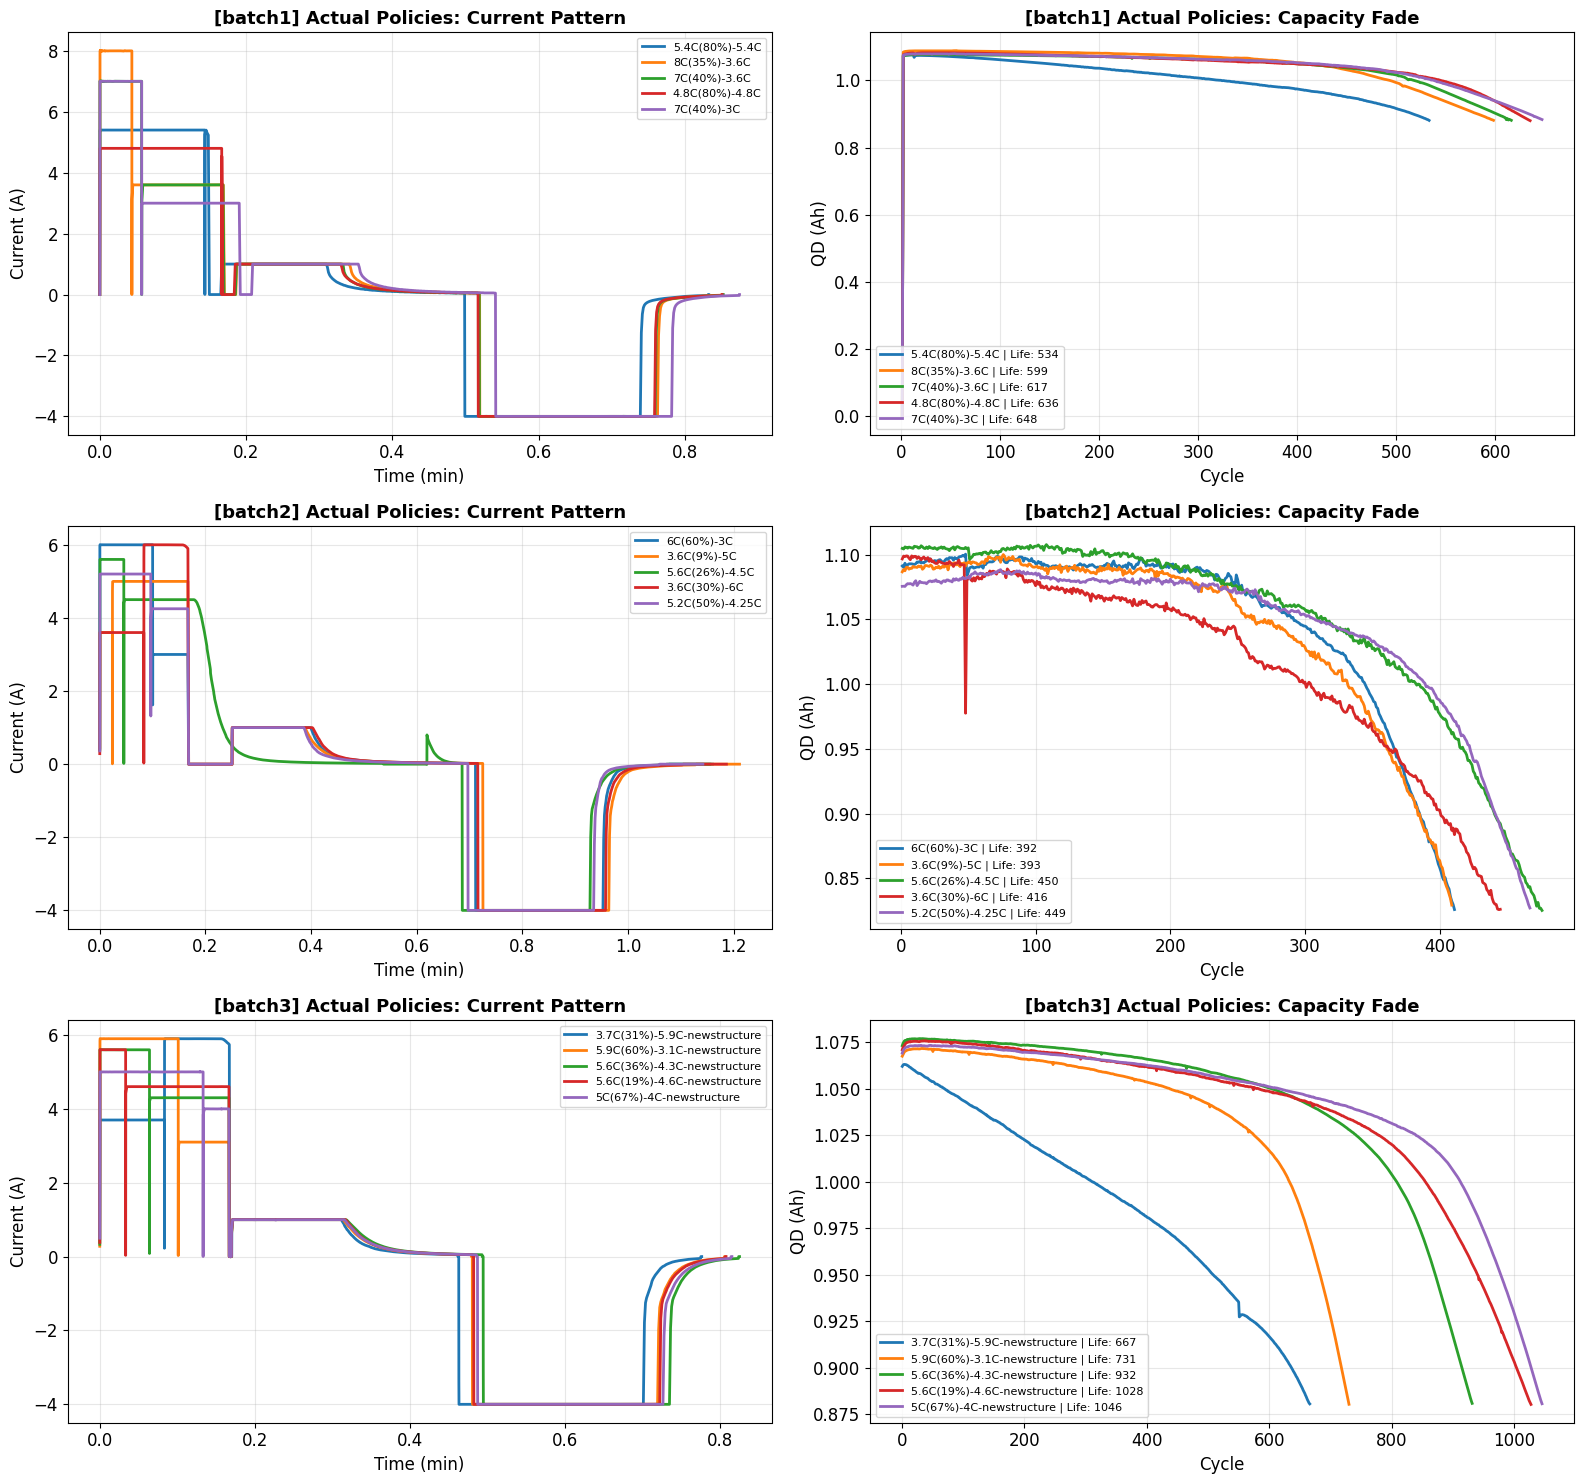

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 헬퍼 함수 ---
def to_cycle_list(cycles_raw):
    if isinstance(cycles_raw, dict):
        keys = list(cycles_raw.keys())
        return [{k: cycles_raw[k][i] for k in keys} for i in range(len(cycles_raw[keys[0]]))]
    return cycles_raw

def first_valid_cycle(cycles):
    for idx, cyc in enumerate(cycles, start=1):
        if isinstance(cyc.get('I'), np.ndarray) and isinstance(cyc.get('t'), np.ndarray):
            return idx, cyc
    return None, None

# 1. 시각화 설정 (배치 개수만큼 행 생성)
batch_names = list(batches.keys())
fig, axes = plt.subplots(len(batch_names), 2, figsize=(16, 5 * len(batch_names)))

representatives = []

for i, b_name in enumerate(batch_names):
    target_batch = batches[b_name]['batch']
    target_df = batches[b_name]['df']
    target_cycle_life_df = batches[b_name]['cycle_life_df']
    
    # 해당 배치에 실제로 존재하는 정책들 추출 (최대 5개만 선별)
    available_policies = target_cycle_life_df['charging_policy'].unique()[:5]
    
    ax_curr = axes[i, 0]
    ax_fade = axes[i, 1]
    
    for policy in available_policies:
        # 배치 내 해당 정책 셀들
        subset = target_cycle_life_df[target_cycle_life_df['charging_policy'] == policy]
        if subset.empty: continue
            
        # 대표 셀 선정 (평균 수명에 가장 가까운 셀)
        target_mean = subset['cycle_life'].mean()
        rep_row = subset.iloc[(subset['cycle_life'] - target_mean).abs().argsort().iloc[0]]
        cell_id = int(rep_row['cell_id'])
        
        # --- 1) 전류 패턴 (Time vs Current) ---
        cell_raw = target_batch[cell_id]
        cycles = to_cycle_list(cell_raw['cycles'])
        c_idx, c_data = first_valid_cycle(cycles)
        
        if c_data is not None:
            t_min = np.asarray(c_data['t']) / 60.0
            current = np.asarray(c_data['I'])
            ax_curr.plot(t_min, current, linewidth=2, label=f'{policy}')

        # --- 2) 용량 감소 (Cycle vs QD) ---
        cell_history = target_df[target_df['cell_id'] == cell_id]
        ax_fade.plot(cell_history['cycle'], cell_history['QD'], linewidth=2,
                     label=f'{policy} | Life: {int(rep_row["cycle_life"])}')

        representatives.append({
            'batch': b_name, 'policy': policy, 'cell_id': cell_id, 'life': int(rep_row['cycle_life'])
        })

    # 서브플롯 타이틀 및 라벨
    ax_curr.set_title(f'[{b_name}] Actual Policies: Current Pattern', fontsize=13, fontweight='bold')
    ax_curr.set_xlabel('Time (min)'); ax_curr.set_ylabel('Current (A)')
    ax_curr.legend(fontsize=8, loc='upper right'); ax_curr.grid(alpha=0.3)

    ax_fade.set_title(f'[{b_name}] Actual Policies: Capacity Fade', fontsize=13, fontweight='bold')
    ax_fade.set_xlabel('Cycle'); ax_fade.set_ylabel('QD (Ah)')
    ax_fade.legend(fontsize=8, loc='lower left'); ax_fade.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 충전 조건 (C-rate)과 수명의 관계는?


### 5.1 초기 사이클 피쳐들과 Cycle Life 상관 계수 확인 /  5.2 가장 강한 관계 식별 

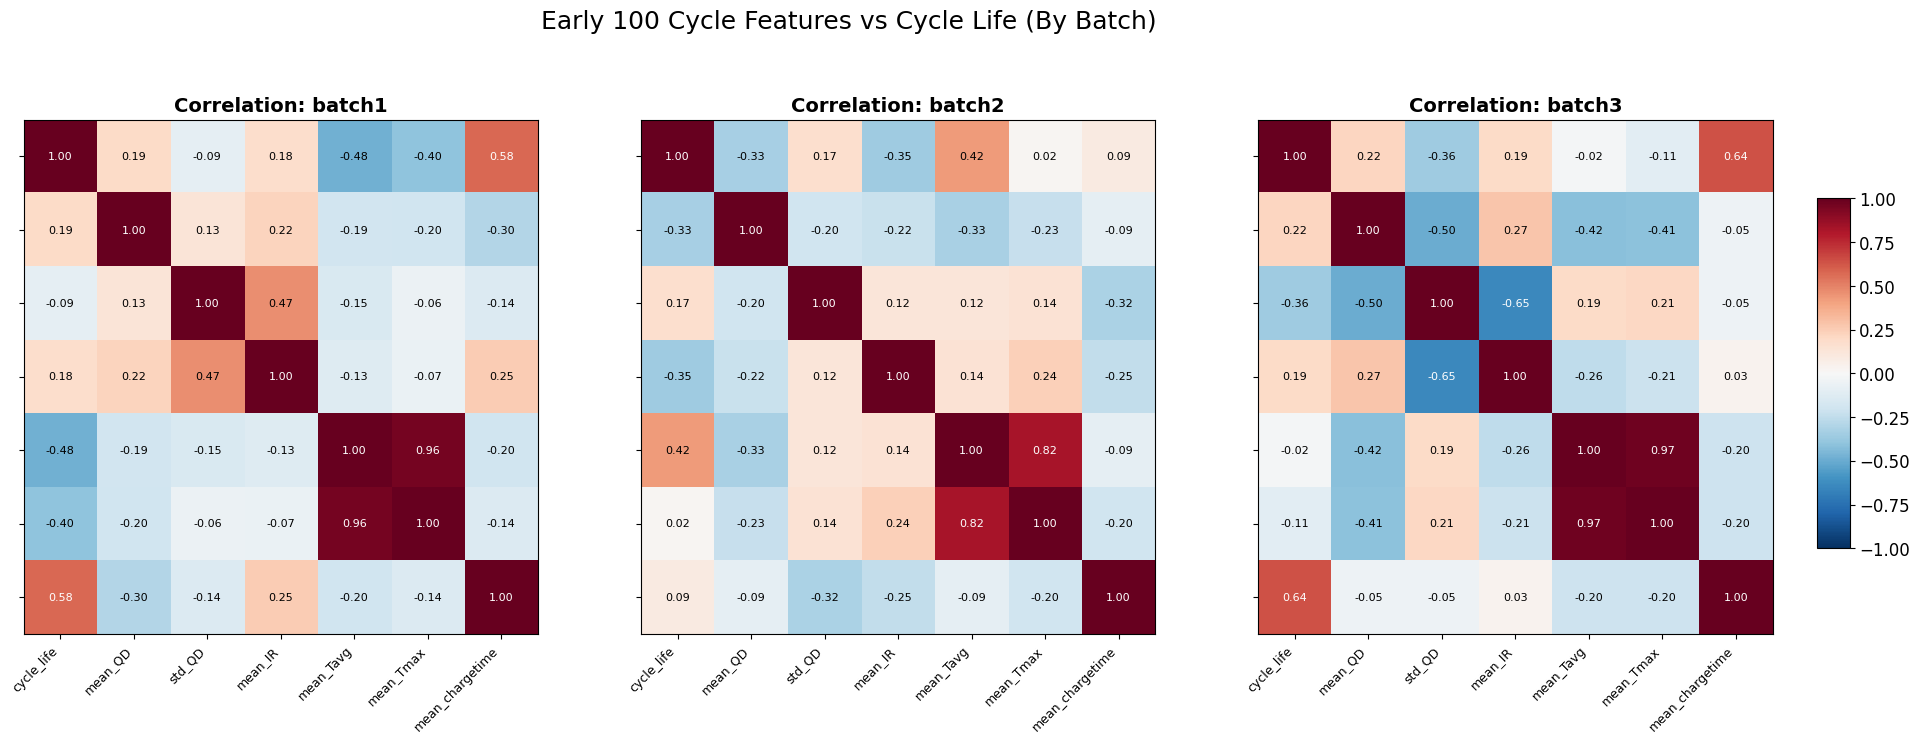


      [cycle_life Correlation Ranking by Batch]       


,batch1,batch2,batch3
mean_chargetime,0.577,0.087,0.637
mean_Tavg,-0.482,0.425,-0.022
mean_Tmax,-0.404,0.019,-0.106
mean_QD,0.193,-0.332,0.217
mean_IR,0.177,-0.353,0.190
std_QD,-0.090,0.171,-0.356


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. 시각화 설정 (1행 3열)
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
batch_names = list(batches.keys())

for i, name in enumerate(batch_names):
    ax = axes[i]
    df_curr = batches[name]['df']
    
    # 2. 해당 배치의 초기 100 사이클 데이터 집계
    # cell_id별로 그룹화하여 초기 특성 추출
    early = df_curr[df_curr['cycle'] <= 100].groupby('cell_id').agg(
        cycle_life      = ('cycle_life', 'first'),
        mean_QD         = ('QD', 'mean'),
        std_QD          = ('QD', 'std'),
        mean_IR         = ('IR', 'mean'),
        mean_Tavg       = ('Tavg', 'mean'),
        mean_Tmax       = ('Tmax', 'mean'),
        mean_chargetime = ('chargetime', 'mean'),
    ).reset_index(drop=True)

    # 3. 상관계수 행렬 계산
    corr_matrix = early.corr()
    
    # 4. 히트맵 그리기
    im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    
    # 레이블 설정
    labels = corr_matrix.columns.tolist()
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    if i == 0:
        ax.set_yticklabels(labels, fontsize=9)
    else:
        ax.set_yticklabels([])

    # 셀 안에 수치 표시
    for row in range(len(labels)):
        for col in range(len(labels)):
            val = corr_matrix.iloc[row, col]
            # 상관관계가 높으면 흰색, 낮으면 검은색 글씨
            text_color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(col, row, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color=text_color)

    ax.set_title(f'Correlation: {name}', fontsize=14, fontweight='bold')

# 컬러바 추가
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.25, 0.015, 0.5])
fig.colorbar(im, cax=cbar_ax)

plt.suptitle('Early 100 Cycle Features vs Cycle Life (By Batch)', fontsize=18, y=1.02)
plt.show()

# 5. 수명(cycle_life)과의 상관계수 순위 통합 출력
print("\n" + "="*60)
print(f"{'[cycle_life Correlation Ranking by Batch]':^54}")
print("="*60)

rank_list = []
for name in batch_names:
    # 각 배치별 corr 다시 계산하여 순위 추출
    df_curr = batches[name]['df']
    early = df_curr[df_curr['cycle'] <= 100].groupby('cell_id').agg(
        cycle_life=('cycle_life', 'first'), mean_QD=('QD', 'mean'), 
        std_QD=('QD', 'std'), mean_IR=('IR', 'mean'), 
        mean_Tavg=('Tavg', 'mean'), mean_Tmax=('Tmax', 'mean'), 
        mean_chargetime=('chargetime', 'mean')
    )
    corr = early.corr()['cycle_life'].drop('cycle_life')
    corr.name = name
    rank_list.append(corr)

# 배치를 컬럼으로 합쳐서 출력
rank_df = pd.concat(rank_list, axis=1)
display(rank_df.sort_values(by=batch_names[0], key=abs, ascending=False).round(3))

### 5.3 멀티클리니어리티 문제 확인 

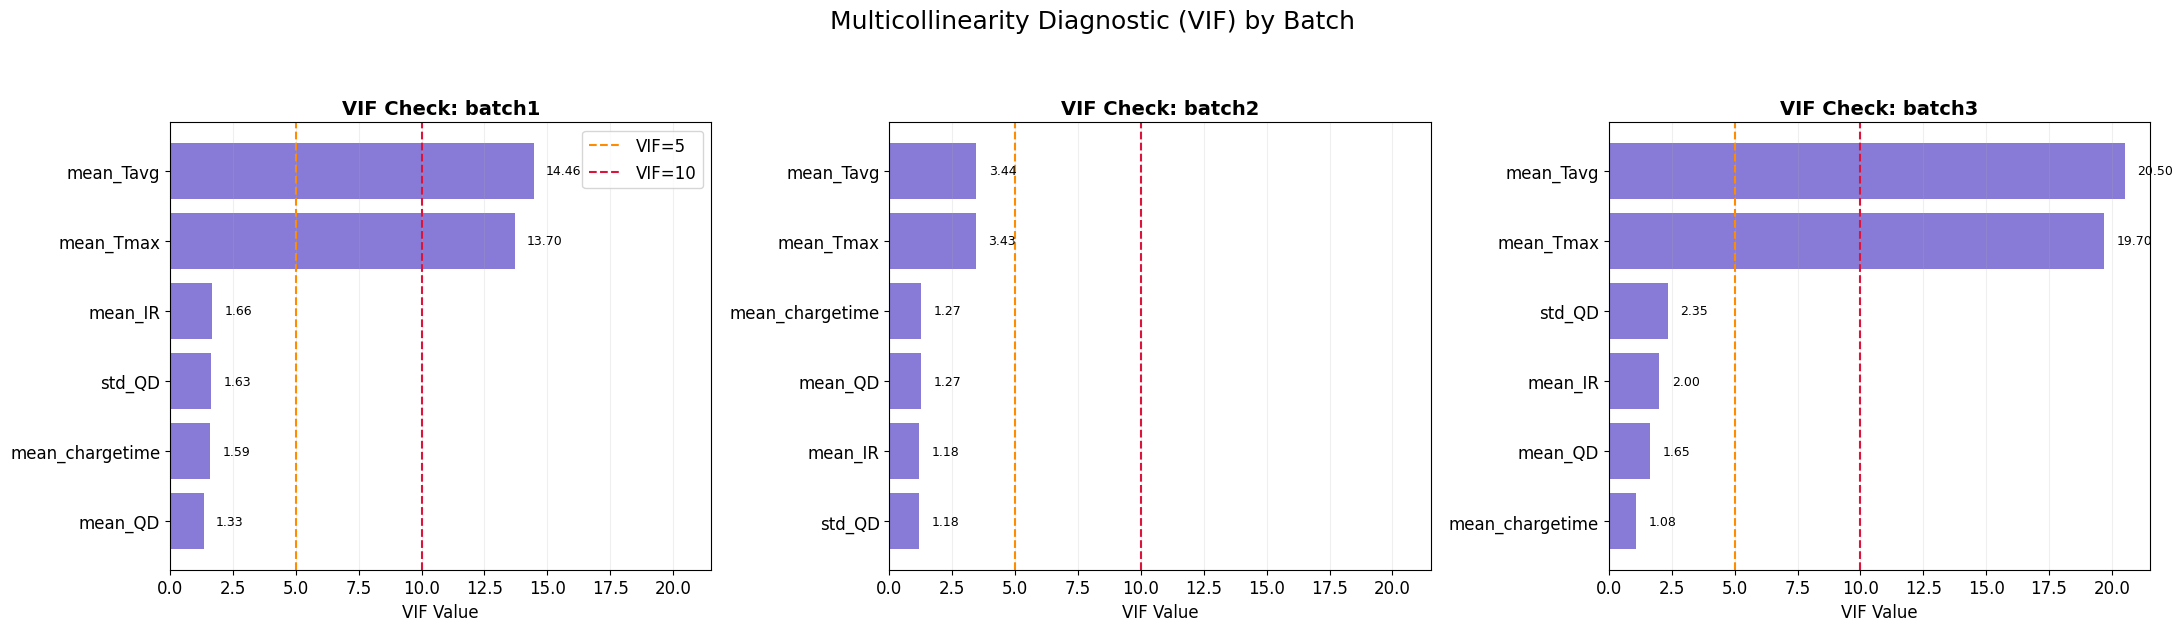


                [VIF Comparison Table]                


batch,batch1,batch2,batch3
feature,,,
mean_IR,1.659000,1.181000,1.995000
mean_QD,1.333000,1.271000,1.645000
mean_Tavg,14.456000,3.442000,20.502000
mean_Tmax,13.699000,3.433000,19.700000
mean_chargetime,1.589000,1.274000,1.084000
std_QD,1.631000,1.181000,2.351000


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 분석 대상 피처 설정
feature_only_cols = ['mean_QD', 'std_QD', 'mean_IR', 'mean_Tavg', 'mean_Tmax', 'mean_chargetime']
batch_names = list(batches.keys())

# 2. 시각화 설정 (1행 3열)
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharex=True)
all_vif_results = []

for i, name in enumerate(batch_names):
    ax = axes[i]
    df_curr = batches[name]['df']
    
    # 해당 배치의 초기 100 사이클 데이터 집계
    early = df_curr[df_curr['cycle'] <= 100].groupby('cell_id').agg(
        mean_QD=('QD', 'mean'),
        std_QD=('QD', 'std'),
        mean_IR=('IR', 'mean'),
        mean_Tavg=('Tavg', 'mean'),
        mean_Tmax=('Tmax', 'mean'),
        mean_chargetime=('chargetime', 'mean'),
    ).dropna().reset_index(drop=True)

    # VIF 계산 로직 (Matrix 연산 기반)
    vif_rows = []
    X = early[feature_only_cols].to_numpy(dtype=float)

    for idx, col in enumerate(feature_only_cols):
        y = X[:, idx]
        # 타겟 피처를 제외한 나머지 피처들
        X_other = np.delete(X, idx, axis=1)
        # 상수항(Intercept) 추가
        X_other = np.column_stack([np.ones(len(X_other)), X_other])
        
        # 최소제곱법(OLS)으로 R-squared 계산
        try:
            coef, *_ = np.linalg.lstsq(X_other, y, rcond=None)
            y_pred = X_other @ coef
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - y.mean()) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
            vif = np.inf if 1 - r2 < 1e-12 else 1 / (1 - r2)
        except:
            vif = np.nan
            
        vif_rows.append({'feature': col, 'VIF': round(vif, 3), 'batch': name})

    # 데이터프레임 변환 및 시각화용 정렬
    vif_df_curr = pd.DataFrame(vif_rows).sort_values('VIF', ascending=True)
    all_vif_results.append(vif_df_curr)
    
    # 3. 가로 바 차트 그리기
    bars = ax.barh(vif_df_curr['feature'], vif_df_curr['VIF'], color='slateblue', alpha=0.8)
    
    # 임계치 가이드라인 (VIF=5, VIF=10)
    ax.axvline(5, color='darkorange', linestyle='--', linewidth=1.5, label='VIF=5')
    ax.axvline(10, color='crimson', linestyle='--', linewidth=1.5, label='VIF=10')
    
    # 수치 텍스트 표시
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.2f}', 
                va='center', ha='left', fontsize=9)

    ax.set_title(f'VIF Check: {name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('VIF Value')
    ax.grid(axis='x', alpha=0.2)
    if i == 0:
        ax.legend()

plt.suptitle('Multicollinearity Diagnostic (VIF) by Batch', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

# 4. 통합 결과 테이블 출력
total_vif_df = pd.concat(all_vif_results).pivot(index='feature', columns='batch', values='VIF')
print("\n" + "="*60)
print(f"{'[VIF Comparison Table]':^54}")
print("="*60)
display(total_vif_df.style.applymap(lambda x: 'color: red; font-weight: bold' if x > 10 else ('color: orange' if x > 5 else '')))

# 파생변수

## 파생변수 정밀 스크리닝 (EDA 통합)

아래 셀은 `batch1/2/3` 전체를 동시에 보고,
- 배치별 상관계수
- 부호 일관성
- 배치 간 변동성
을 종합해 파생변수 후보를 점수화합니다.

또한 `knee_*`, `*margin*` 같은 **잠재 누수 위험 변수**를 자동으로 분리해,
`실전 투입 추천 변수`를 따로 제시합니다.


In [47]:
import numpy as np
import pandas as pd
from IPython.display import display

if 'batches' not in globals() or not batches:
    raise ValueError("먼저 `batches` 생성 셀을 실행해주세요.")


def _safe_corr(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 8:
        return np.nan
    xs = np.asarray(x[m])
    if np.unique(xs).size <= 1:
        return np.nan
    return float(np.corrcoef(xs, np.asarray(y[m]))[0, 1])


def _safe_slope(cycle, value):
    x = np.asarray(cycle, dtype=float)
    y = np.asarray(value, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 2:
        return np.nan
    return float(np.polyfit(x[m], y[m], 1)[0])


def build_feature_table(obj, early_cutoff=100):
    df = obj['df'].copy()
    life = obj['cycle_life_df'].copy()
    knee = obj.get('knee_summary', pd.DataFrame()).copy()
    delta = obj.get('delta_q', pd.DataFrame()).copy()

    base = (
        df[df['cycle'] <= 5]
        .groupby('cell_id')
        .agg(
            baseline_qd=('QD', 'median'),
            baseline_ir=('IR', 'median'),
            baseline_tavg=('Tavg', 'median'),
            baseline_ct=('chargetime', 'median'),
        )
        .reset_index()
    )

    early = df[(df['cycle'] <= early_cutoff) & (df['cycle_life'] > 0)].copy()

    rows = []
    for cell_id, g in early.groupby('cell_id'):
        g = g.sort_values('cycle')
        last = g.iloc[-1]
        b = base[base['cell_id'] == cell_id]

        b_qd = b['baseline_qd'].iloc[0] if len(b) else np.nan
        b_ir = b['baseline_ir'].iloc[0] if len(b) else np.nan
        b_tavg = b['baseline_tavg'].iloc[0] if len(b) else np.nan
        b_ct = b['baseline_ct'].iloc[0] if len(b) else np.nan

        qd_drop_100 = b_qd - last['QD'] if pd.notna(b_qd) else np.nan
        qd_fade_pct_100 = qd_drop_100 / b_qd if pd.notna(b_qd) and b_qd != 0 else np.nan
        ir_rise_pct_100 = (last['IR'] / b_ir) - 1 if pd.notna(b_ir) and b_ir != 0 else np.nan
        temp_shift_100 = last['Tavg'] - b_tavg if pd.notna(b_tavg) else np.nan
        ct_shift_100 = last['chargetime'] - b_ct if pd.notna(b_ct) else np.nan

        rows.append({
            'cell_id': cell_id,
            'cycle_life': float(g['cycle_life'].iloc[0]),
            'early_qd_mean': float(g['QD'].mean()),
            'early_qd_std': float(g['QD'].std()),
            'early_ir_mean': float(g['IR'].mean()),
            'early_tavg_mean': float(g['Tavg'].mean()),
            'early_temp_span_mean': float((g['Tmax'] - g['Tmin']).mean()),
            'early_ct_mean': float(g['chargetime'].mean()),
            'qd_drop_100': qd_drop_100,
            'qd_fade_pct_100': qd_fade_pct_100,
            'ir_rise_pct_100': ir_rise_pct_100,
            'temp_shift_100': temp_shift_100,
            'ct_shift_100': ct_shift_100,
            'qd_slope_100': _safe_slope(g['cycle'], g['QD']),
            'ir_slope_100': _safe_slope(g['cycle'], g['IR']),
            'tavg_slope_100': _safe_slope(g['cycle'], g['Tavg']),
        })

    feat = pd.DataFrame(rows)

    policy_cols = [c for c in ['cell_id', 'max_c_rate', 'mean_c_rate', 'switch_soc_pct', 'policy_steps'] if c in life.columns]
    feat = feat.merge(life[policy_cols], on='cell_id', how='left')

    if len(knee):
        knee_cols = [c for c in ['cell_id', 'knee_cycle', 'baseline_fade_rate', 'post_knee_fade_rate', 'fade_acceleration_ratio'] if c in knee.columns]
        feat = feat.merge(knee[knee_cols], on='cell_id', how='left')

    if len(delta):
        delta_cols = [c for c in ['cell_id', 'delta_q_std', 'delta_q_range', 'delta_q_min', 'delta_q_midV_mean', 'delta_q_highV_mean'] if c in delta.columns]
        feat = feat.merge(delta[delta_cols], on='cell_id', how='left')

    # 상호작용 파생변수
    feat['c_rate_x_ir_rise'] = feat['mean_c_rate'] * feat['ir_rise_pct_100']
    feat['c_rate_x_temp_shift'] = feat['mean_c_rate'] * feat['temp_shift_100']
    feat['deltaq_x_fade'] = feat['delta_q_std'] * feat['qd_fade_pct_100']
    feat['ir_x_temp'] = feat['ir_rise_pct_100'] * feat['temp_shift_100']
    feat['stress_index_100'] = feat['qd_fade_pct_100'] * (1 + feat['ir_rise_pct_100']) * (1 + feat['temp_shift_100'].fillna(0) / 100)

    if 'knee_cycle' in feat.columns:
        feat['knee_margin'] = feat['cycle_life'] - feat['knee_cycle']
        feat['knee_ratio'] = feat['knee_cycle'] / feat['cycle_life'].replace(0, np.nan)

    return feat.replace([np.inf, -np.inf], np.nan)


# 1) batch별 feature table 생성
feat_by_batch = {name: build_feature_table(obj) for name, obj in batches.items()}

print('[생성 완료]')
for name, t in feat_by_batch.items():
    print(f'- {name}: {t.shape}')

# 2) 후보 feature 스코어링
all_feats = set()
for t in feat_by_batch.values():
    all_feats.update([c for c in t.columns if c not in ['cell_id', 'cycle_life']])

rows = []
for f in sorted(all_feats):
    row = {'feature': f}
    corrs, signs = [], []
    for b in ['batch1', 'batch2', 'batch3']:
        t = feat_by_batch[b]
        if f not in t.columns:
            row[f'{b}_corr'] = np.nan
            continue
        c = _safe_corr(t[f].to_numpy(), t['cycle_life'].to_numpy())
        row[f'{b}_corr'] = c
        if pd.notna(c):
            corrs.append(c)
            signs.append(np.sign(c))

    row['valid_batches'] = int(np.sum(pd.notna([row['batch1_corr'], row['batch2_corr'], row['batch3_corr']])))
    row['mean_abs_corr'] = float(np.nanmean(np.abs(corrs))) if corrs else np.nan
    row['std_corr'] = float(np.nanstd(corrs)) if len(corrs) > 1 else np.nan
    row['sign_consistent'] = int(len(signs) >= 2 and len(set(signs)) == 1)
    rows.append(row)

score_df = pd.DataFrame(rows)
penalty_fill = score_df['std_corr'].max(skipna=True) if score_df['std_corr'].notna().any() else 0
score_df['score'] = (
    score_df['mean_abs_corr'].fillna(0)
    - 0.5 * score_df['std_corr'].fillna(penalty_fill)
    + 0.05 * score_df['sign_consistent'].fillna(0)
)
ranked = score_df.sort_values(['score', 'mean_abs_corr'], ascending=False).reset_index(drop=True)

# 3) 누수 위험 변수 분리
leakage_keywords = ['knee', 'margin']
ranked['is_leakage_risk'] = ranked['feature'].apply(lambda x: any(k in x.lower() for k in leakage_keywords))

shortlist_all = ranked[(ranked['valid_batches'] >= 2) & (ranked['mean_abs_corr'] >= 0.20)].copy()
shortlist_prod = shortlist_all[~shortlist_all['is_leakage_risk']].copy()

print('\n[Top 20 - 전체 파생변수 랭킹]')
display(ranked[['feature', 'batch1_corr', 'batch2_corr', 'batch3_corr', 'mean_abs_corr', 'std_corr', 'sign_consistent', 'is_leakage_risk', 'score']].head(20).round(3))

print('\n[Shortlist - 전체 기준(누수 위험 포함)]')
display(shortlist_all[['feature', 'batch1_corr', 'batch2_corr', 'batch3_corr', 'mean_abs_corr', 'std_corr', 'sign_consistent', 'is_leakage_risk', 'score']].head(20).round(3))

print('\n[Shortlist - 실전 투입 권장(누수 위험 제외)]')
display(shortlist_prod[['feature', 'batch1_corr', 'batch2_corr', 'batch3_corr', 'mean_abs_corr', 'std_corr', 'sign_consistent', 'score']].head(20).round(3))

recommended = shortlist_prod['feature'].head(12).tolist()
print('\n실전 추천 파생변수 12개:')
for i, f in enumerate(recommended, 1):
    print(f'{i:>2}. {f}')


[생성 완료]
- batch1: (46, 36)
- batch2: (39, 36)
- batch3: (44, 36)

[Top 20 - 전체 파생변수 랭킹]


,feature,batch1_corr,batch2_corr,batch3_corr,mean_abs_corr,std_corr,sign_consistent,is_leakage_risk,score
0,knee_margin,0.998,NaN,0.964,0.981,0.017,1,True,1.023
1,delta_q_min,0.882,0.819,0.692,0.797,0.079,1,False,0.808
2,delta_q_std,-0.894,-0.835,-0.673,0.800,0.093,1,False,0.804
3,delta_q_midV_mean,0.881,0.819,0.664,0.788,0.091,1,False,0.793
4,delta_q_highV_mean,0.804,0.791,0.669,0.755,0.061,1,False,0.774
5,delta_q_range,-0.882,-0.802,-0.601,0.762,0.118,1,False,0.752
6,knee_ratio,-0.797,NaN,-0.438,0.618,0.180,1,True,0.578
7,post_knee_fade_rate,0.525,NaN,0.392,0.459,0.066,1,True,0.475
8,max_c_rate,-0.580,-0.161,-0.657,0.466,0.218,1,False,0.407
9,knee_cycle,-0.319,NaN,-0.314,0.316,0.002,1,True,0.365



[Shortlist - 전체 기준(누수 위험 포함)]


,feature,batch1_corr,batch2_corr,batch3_corr,mean_abs_corr,std_corr,sign_consistent,is_leakage_risk,score
0,knee_margin,0.998,NaN,0.964,0.981,0.017,1,True,1.023
1,delta_q_min,0.882,0.819,0.692,0.797,0.079,1,False,0.808
2,delta_q_std,-0.894,-0.835,-0.673,0.800,0.093,1,False,0.804
3,delta_q_midV_mean,0.881,0.819,0.664,0.788,0.091,1,False,0.793
4,delta_q_highV_mean,0.804,0.791,0.669,0.755,0.061,1,False,0.774
5,delta_q_range,-0.882,-0.802,-0.601,0.762,0.118,1,False,0.752
6,knee_ratio,-0.797,NaN,-0.438,0.618,0.180,1,True,0.578
7,post_knee_fade_rate,0.525,NaN,0.392,0.459,0.066,1,True,0.475
8,max_c_rate,-0.580,-0.161,-0.657,0.466,0.218,1,False,0.407
9,knee_cycle,-0.319,NaN,-0.314,0.316,0.002,1,True,0.365



[Shortlist - 실전 투입 권장(누수 위험 제외)]


,feature,batch1_corr,batch2_corr,batch3_corr,mean_abs_corr,std_corr,sign_consistent,score
1,delta_q_min,0.882,0.819,0.692,0.797,0.079,1,0.808
2,delta_q_std,-0.894,-0.835,-0.673,0.800,0.093,1,0.804
3,delta_q_midV_mean,0.881,0.819,0.664,0.788,0.091,1,0.793
4,delta_q_highV_mean,0.804,0.791,0.669,0.755,0.061,1,0.774
5,delta_q_range,-0.882,-0.802,-0.601,0.762,0.118,1,0.752
8,max_c_rate,-0.580,-0.161,-0.657,0.466,0.218,1,0.407
10,early_ct_mean,0.577,0.087,0.637,0.434,0.246,1,0.361
11,switch_soc_pct,0.235,0.116,0.541,0.297,0.179,1,0.258
12,early_temp_span_mean,-0.353,-0.205,-0.140,0.233,0.089,1,0.238
13,baseline_fade_rate,0.508,-0.255,0.357,0.373,0.330,0,0.208



실전 추천 파생변수 12개:
 1. delta_q_min
 2. delta_q_std
 3. delta_q_midV_mean
 4. delta_q_highV_mean
 5. delta_q_range
 6. max_c_rate
 7. early_ct_mean
 8. switch_soc_pct
 9. early_temp_span_mean
10. baseline_fade_rate
11. qd_drop_100
12. qd_fade_pct_100


## 고급 피쳐 엔지니어링: 열화 메커니즘 기반 변수 탐색

기존 스크리닝 한계:
- 대부분 **평균/기울기** 수준의 1차 통계량 → 열화의 **역학 변화**(가속? 감속?) 미포착
- **쿨롱 효율**, **IR-QD 결합**, **충전 수용능력** 등 물리적 메커니즘 반영 부재

### 추가 탐색 관점

| 관점 | 핵심 질문 | 생성 변수 |
|------|----------|----------|
| 열화 역학 | 용량 감소가 **가속**되는가? | `qd_curvature`, `fade_acceleration`, `qd_residual_std`, `qd_diff_std` |
| 쿨롱 효율 | 충방전 효율이 **악화**되는가? | `ce_mean`, `ce_slope`, `ce_range` |
| IR-QD 결합 | 저항 증가가 용량 감소를 **유발**하는가? | `ir_qd_coupling`, `ir_curvature` |
| 초기 거동 | **포밍 효과**, 측정 잡음 크기 | `initial_bump`, `qd_cv` |
| 충전 수용능력 | 충전 효율이 **떨어지고** 있는가? | `charge_accept_slope`, `ct_slope` |
| 물리 상호작용 | C-rate가 비선형 열화를 **가속**하는가? | `crate_x_curvature`, `crate_x_ce_slope` |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display

if 'batches' not in globals() or not batches:
    raise ValueError('먼저 batches 생성 셀을 실행하세요.')

try:
    _safe_slope, _safe_corr
except NameError:
    def _safe_slope(x, y):
        x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
        m = np.isfinite(x) & np.isfinite(y)
        return float(np.polyfit(x[m], y[m], 1)[0]) if m.sum() >= 2 else np.nan
    def _safe_corr(x, y):
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 8: return np.nan
        xs = np.asarray(x[m])
        return float(np.corrcoef(xs, np.asarray(y[m]))[0, 1]) if np.unique(xs).size > 1 else np.nan


def build_advanced_features(obj, early_cutoff=100):
    df = obj['df'].copy()
    life = obj['cycle_life_df'].copy()

    rows = []
    for cell_id, g in df[df['cycle'] <= early_cutoff].groupby('cell_id'):
        g = g.sort_values('cycle')
        if len(g) < 20:
            continue

        cy = g['cycle'].values.astype(float)
        qd = g['QD'].values.astype(float)
        qc = g['QC'].values.astype(float)
        ir = g['IR'].values.astype(float)
        tavg = g['Tavg'].values.astype(float)
        ct = g['chargetime'].values.astype(float)

        row = {'cell_id': cell_id, 'cycle_life': float(g['cycle_life'].iloc[0])}

        # ── 1. 열화 역학: QD 곡률 (2차 가속도) ──
        m_qd = np.isfinite(cy) & np.isfinite(qd)
        if m_qd.sum() >= 10:
            coeffs = np.polyfit(cy[m_qd], qd[m_qd], 2)
            row['qd_curvature'] = float(coeffs[0])
            pred = np.polyval(coeffs, cy[m_qd])
            row['qd_residual_std'] = float(np.std(qd[m_qd] - pred))
        else:
            row['qd_curvature'] = np.nan
            row['qd_residual_std'] = np.nan

        # 구간별 기울기 비: 전반 50 vs 후반 50
        mid = early_cutoff // 2
        g1, g2 = g[g['cycle'] <= mid], g[g['cycle'] > mid]
        s1 = _safe_slope(g1['cycle'].values, g1['QD'].values) if len(g1) >= 5 else np.nan
        s2 = _safe_slope(g2['cycle'].values, g2['QD'].values) if len(g2) >= 5 else np.nan
        row['fade_acceleration'] = float(s2 / s1) if pd.notna(s1) and pd.notna(s2) and s1 != 0 else np.nan

        # 사이클 간 QD 변화량의 잡음
        qd_diff = np.diff(qd)
        valid_diff = qd_diff[np.isfinite(qd_diff)]
        row['qd_diff_std'] = float(np.std(valid_diff)) if len(valid_diff) > 2 else np.nan
        if len(valid_diff) > 5 and np.std(valid_diff) > 0:
            m3 = np.mean((valid_diff - np.mean(valid_diff))**3)
            row['qd_diff_skew'] = float(m3 / np.std(valid_diff)**3)
        else:
            row['qd_diff_skew'] = np.nan

        # ── 2. 쿨롱 효율 (CE = QD/QC) ──
        ce = np.where((qc > 0) & np.isfinite(qc) & np.isfinite(qd), qd / qc, np.nan)
        valid_ce = ce[np.isfinite(ce)]
        row['ce_mean'] = float(np.nanmean(valid_ce)) if len(valid_ce) > 0 else np.nan
        row['ce_slope'] = _safe_slope(cy, ce)
        row['ce_range'] = float(np.nanmax(valid_ce) - np.nanmin(valid_ce)) if len(valid_ce) > 2 else np.nan

        # ── 3. IR-QD 결합 (셀 내부 상관) ──
        v_iq = np.isfinite(ir) & np.isfinite(qd)
        if v_iq.sum() >= 5 and np.unique(ir[v_iq]).size > 1:
            row['ir_qd_coupling'] = float(np.corrcoef(ir[v_iq], qd[v_iq])[0, 1])
        else:
            row['ir_qd_coupling'] = np.nan

        # IR 곡률 (저항 증가 가속도)
        m_ir = np.isfinite(cy) & np.isfinite(ir)
        if m_ir.sum() >= 10:
            row['ir_curvature'] = float(np.polyfit(cy[m_ir], ir[m_ir], 2)[0])
        else:
            row['ir_curvature'] = np.nan

        # ── 4. 초기 거동 이상 ──
        early20 = qd[:min(20, len(qd))]
        valid20 = early20[np.isfinite(early20)]
        first_qd = qd[0] if np.isfinite(qd[0]) else np.nan
        row['initial_bump'] = float(np.nanmax(valid20) / first_qd - 1) \
            if pd.notna(first_qd) and first_qd > 0 and len(valid20) > 0 else np.nan

        qd_valid = qd[np.isfinite(qd)]
        qd_m = np.mean(qd_valid) if len(qd_valid) > 0 else 0
        row['qd_cv'] = float(np.std(qd_valid) / qd_m) if qd_m > 0 else np.nan

        # ── 5. 충전 수용능력 변화 ──
        cre = np.where((ct > 0) & np.isfinite(ct) & np.isfinite(qc), qc / ct, np.nan)
        row['charge_accept_slope'] = _safe_slope(cy, cre)
        row['ct_slope'] = _safe_slope(cy, ct)

        # 온도-QD 민감도
        v_tq = np.isfinite(tavg) & np.isfinite(qd)
        if v_tq.sum() >= 5 and np.unique(tavg[v_tq]).size > 1:
            row['temp_qd_sensitivity'] = float(np.corrcoef(tavg[v_tq], qd[v_tq])[0, 1])
        else:
            row['temp_qd_sensitivity'] = np.nan

        rows.append(row)

    feat = pd.DataFrame(rows)

    policy_cols = [c for c in ['cell_id', 'mean_c_rate', 'max_c_rate'] if c in life.columns]
    if policy_cols:
        feat = feat.merge(life[policy_cols], on='cell_id', how='left')

    # ── 6. 물리 기반 상호작용 ──
    if 'mean_c_rate' in feat.columns:
        feat['crate_x_curvature'] = feat['mean_c_rate'] * feat['qd_curvature']
        feat['crate_x_ce_slope'] = feat['mean_c_rate'] * feat['ce_slope']
        feat['crate_x_ir_curv'] = feat['mean_c_rate'] * feat['ir_curvature']
    feat['coupling_x_jitter'] = feat['ir_qd_coupling'] * feat['qd_diff_std']
    feat['bump_x_fade'] = feat['initial_bump'] * feat['fade_acceleration']

    return feat.replace([np.inf, -np.inf], np.nan)


# ═══════════════════════════════════════════════
# 배치별 고급 피쳐 생성
# ═══════════════════════════════════════════════
adv_by_batch = {name: build_advanced_features(obj) for name, obj in batches.items()}

print('[고급 피쳐 생성 완료]')
for name, t in adv_by_batch.items():
    print(f'  {name}: {t.shape}')

# ═══════════════════════════════════════════════
# 스코어링
# ═══════════════════════════════════════════════
exclude = {'cell_id', 'cycle_life', 'mean_c_rate', 'max_c_rate'}
adv_feats = set()
for t in adv_by_batch.values():
    adv_feats.update([c for c in t.columns if c not in exclude])

rows = []
for f in sorted(adv_feats):
    row = {'feature': f}
    corrs, signs = [], []
    for b in ['batch1', 'batch2', 'batch3']:
        t = adv_by_batch[b]
        if f not in t.columns:
            row[f'{b}_corr'] = np.nan
            continue
        c = _safe_corr(t[f].to_numpy(), t['cycle_life'].to_numpy())
        row[f'{b}_corr'] = c
        if pd.notna(c):
            corrs.append(c)
            signs.append(np.sign(c))
    row['valid_batches'] = int(np.sum(pd.notna(
        [row.get('batch1_corr'), row.get('batch2_corr'), row.get('batch3_corr')])))
    row['mean_abs_corr'] = float(np.nanmean(np.abs(corrs))) if corrs else np.nan
    row['std_corr'] = float(np.nanstd(corrs)) if len(corrs) > 1 else np.nan
    row['sign_consistent'] = int(len(signs) >= 2 and len(set(signs)) == 1)
    rows.append(row)

adv_score = pd.DataFrame(rows)
pf = adv_score['std_corr'].max(skipna=True) if adv_score['std_corr'].notna().any() else 0
adv_score['score'] = (
    adv_score['mean_abs_corr'].fillna(0)
    - 0.5 * adv_score['std_corr'].fillna(pf)
    + 0.05 * adv_score['sign_consistent'].fillna(0)
)
adv_ranked = adv_score.sort_values(['score', 'mean_abs_corr'], ascending=False).reset_index(drop=True)

print('\n[고급 파생변수 랭킹]')
display(adv_ranked[['feature', 'batch1_corr', 'batch2_corr', 'batch3_corr',
                     'mean_abs_corr', 'std_corr', 'sign_consistent', 'score']].round(3))

# ═══════════════════════════════════════════════
# 기존(ranked) + 고급 통합 비교
# ═══════════════════════════════════════════════
leakage_kw = ['knee', 'margin']

if 'ranked' in globals():
    prev = ranked[~ranked['feature'].apply(
        lambda x: any(k in x.lower() for k in leakage_kw))].copy()
    prev = prev[['feature', 'batch1_corr', 'batch2_corr', 'batch3_corr',
                  'mean_abs_corr', 'std_corr', 'sign_consistent', 'score']].copy()
    prev['source'] = '기존'

    curr = adv_ranked[['feature', 'batch1_corr', 'batch2_corr', 'batch3_corr',
                        'mean_abs_corr', 'std_corr', 'sign_consistent', 'score']].copy()
    curr['source'] = '★신규'

    combined = pd.concat([prev, curr], ignore_index=True)
    combined = combined.drop_duplicates('feature', keep='last')
    combined = combined.sort_values('score', ascending=False).reset_index(drop=True)
else:
    combined = adv_ranked.copy()
    combined['source'] = '★신규'

print('\n' + '='*70)
print('[통합 랭킹 Top 30 - 기존 + 고급 (누수 변수 제외)]')
print('='*70)
display(combined[['source', 'feature', 'batch1_corr', 'batch2_corr', 'batch3_corr',
                   'mean_abs_corr', 'std_corr', 'sign_consistent', 'score'
                   ]].head(30).round(3))

new_in_top = combined[combined['source'] == '★신규'].head(10)
if len(new_in_top):
    print(f'\n★ 신규 고급 피쳐 중 상위 진입 ★')
    for _, r in new_in_top.iterrows():
        rank = combined[combined['feature'] == r['feature']].index[0] + 1
        print(f'  #{rank:>2}  {r["feature"]:30s}  score={r["score"]:.3f}  |r|={r["mean_abs_corr"]:.3f}')

# ═══════════════════════════════════════════════
# 시각화
# ═══════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

top25 = combined.head(25).copy()
colors = ['#e74c3c' if '신규' in str(s) else '#3498db' for s in top25['source']]
axes[0].barh(range(len(top25)), top25['score'], color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(len(top25)))
axes[0].set_yticklabels(top25['feature'], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Score (|r̄| − 0.5·σ + 0.05·consistency)')
axes[0].set_title('통합 피쳐 랭킹 Top 25', fontsize=13, fontweight='bold')
axes[0].legend(handles=[
    Patch(color='#3498db', label='기존 (1차 스크리닝)'),
    Patch(color='#e74c3c', label='★ 신규 (고급 엔지니어링)')
], loc='lower right', fontsize=10)
axes[0].axvline(x=0, color='gray', linewidth=0.5, linestyle='--')

top20_feats = combined.head(20)['feature'].tolist()
hm_data = []
for f in top20_feats:
    rd = {}
    for b in ['batch1', 'batch2', 'batch3']:
        val = np.nan
        if f in adv_by_batch.get(b, pd.DataFrame()).columns:
            val = _safe_corr(adv_by_batch[b][f].to_numpy(),
                             adv_by_batch[b]['cycle_life'].to_numpy())
        elif 'feat_by_batch' in globals() and f in feat_by_batch.get(b, pd.DataFrame()).columns:
            val = _safe_corr(feat_by_batch[b][f].to_numpy(),
                             feat_by_batch[b]['cycle_life'].to_numpy())
        rd[b] = val
    hm_data.append(rd)

hm = pd.DataFrame(hm_data, index=top20_feats)
im = axes[1].imshow(hm.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(['Batch1', 'Batch2', 'Batch3'], fontsize=11)
axes[1].set_yticks(range(len(hm)))
axes[1].set_yticklabels(hm.index, fontsize=9)
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        v = hm.values[i, j]
        if pd.notna(v):
            axes[1].text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                        color='white' if abs(v) > 0.6 else 'black')
fig.colorbar(im, ax=axes[1], shrink=0.8, label='Pearson r')
axes[1].set_title('배치별 상관계수 히트맵 (Top 20)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════
# 최종 추천 세트
# ═══════════════════════════════════════════════
final = combined[
    (combined['sign_consistent'] == 1) &
    (combined['mean_abs_corr'] >= 0.20) &
    (~combined['feature'].apply(lambda x: any(k in x.lower() for k in leakage_kw)))
].copy()

print('\n' + '='*70)
print('[최종 모델링 추천 피쳐]  조건: 부호 일관 + |r̄|≥0.20 + 누수 제외')
print('='*70)
for i, (_, r) in enumerate(final.iterrows(), 1):
    tag = '★NEW' if '신규' in str(r['source']) else '     '
    print(f'{i:>2}. {tag} {r["feature"]:30s}  score={r["score"]:.3f}  |r̄|={r["mean_abs_corr"]:.3f}')
print(f'\n총 {len(final)}개 → 모델 투입 권장')

final_feature_list = final['feature'].tolist()
